# EDA

This notebook uses `polars` lazy scans to analyze the 7-day train window range from `2025-12-01` to `2025-12-07` without loading the entire dataset into `pandas`.

Scope:
- first 7 days of the train period only
- all four sources
- BTC and ETH
- `polars` for scanning, filtering, grouping, and aggregation
- Bybit liquidation timestamps are shifted by `+200ms` at load time
- convert only small aggregated outputs to `pandas` for plotting


In [1]:
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
pd.options.display.float_format = '{:.5f}'.format
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_rows(20)

ROOT = Path.cwd()
DATA_ROOT = ROOT / 'data'
SYMBOLS = ['btcusdt', 'ethusdt']
SOURCES = {
    'trades': ('binance_trades', 'perp_{symbol}.parquet'),
    'bbo': ('binance_booktickers', 'perp_{symbol}.parquet'),
    'liq_binance': ('binance_liquidations', 'perp_{symbol}.parquet'),
    'liq_bybit': ('bybit_liquidations', '{symbol}.parquet'),
}

TRAIN_START = datetime(2025, 12, 1, tzinfo=timezone.utc)
TRAIN_END_EXCLUSIVE = datetime(2025, 12, 8, tzinfo=timezone.utc)
TRAIN_START_US = int(TRAIN_START.timestamp() * 1_000_000)
TRAIN_END_US = int(TRAIN_END_EXCLUSIVE.timestamp() * 1_000_000)

ROOT

WindowsPath('c:/Users/Sultan/Desktop/projects/task1')

## Helpers

In [2]:
BYBIT_DELAY_US = 200_000


def source_path(source: str, symbol: str) -> Path:
    folder, pattern = SOURCES[source]
    return DATA_ROOT / folder / pattern.format(symbol=symbol)


def scan_train(source: str, symbol: str) -> pl.LazyFrame:
    path = source_path(source, symbol)
    lf = pl.scan_parquet(path)
    if source == 'liq_bybit':
        lf = lf.with_columns((pl.col('timestamp') + BYBIT_DELAY_US).alias('timestamp'))
    return lf.filter(
        (pl.col('timestamp') >= TRAIN_START_US) &
        (pl.col('timestamp') < TRAIN_END_US)
    )


def with_datetime(lf: pl.LazyFrame) -> pl.LazyFrame:
    return lf.with_columns(
        pl.from_epoch(pl.col('timestamp'), time_unit='us').alias('timestamp_dt')
    )


def with_trade_fields(lf: pl.LazyFrame) -> pl.LazyFrame:
    return lf.with_columns(
        (pl.col('price') * pl.col('amount')).alias('notional')
    )


def with_bbo_fields(lf: pl.LazyFrame) -> pl.LazyFrame:
    return lf.with_columns([
        (pl.col('ask_price') - pl.col('bid_price')).alias('spread'),
        ((pl.col('bid_price') + pl.col('ask_price')) / 2.0).alias('mid'),
    ]).with_columns(
        (pl.col('spread') / pl.col('mid') * 10_000.0).alias('spread_bps')
    )


def with_liq_fields(lf: pl.LazyFrame) -> pl.LazyFrame:
    return lf.with_columns(
        (pl.col('price') * pl.col('amount')).alias('notional')
    )


def minute_activity(lf: pl.LazyFrame) -> pl.DataFrame:
    return (
        with_datetime(lf)
        .with_columns(pl.col('timestamp_dt').dt.truncate('1m').alias('minute'))
        .group_by('minute')
        .agg(pl.len().alias('events'))
        .sort('minute')
        .collect()
    )


def day_counts(lf: pl.LazyFrame) -> pl.DataFrame:
    return (
        with_datetime(lf)
        .with_columns(pl.col('timestamp_dt').dt.date().alias('day'))
        .group_by('day')
        .agg(pl.len().alias('events'))
        .sort('day')
        .collect()
    )


def gap_summary(lf: pl.LazyFrame) -> pl.DataFrame:
    return (
        lf.select('timestamp')
        .sort('timestamp')
        .with_columns((pl.col('timestamp').diff() / 1_000.0).alias('gap_ms'))
        .select([
            pl.col('gap_ms').drop_nulls().median().alias('median_gap_ms'),
            pl.col('gap_ms').drop_nulls().quantile(0.99).alias('p99_gap_ms'),
            pl.col('gap_ms').drop_nulls().quantile(0.999).alias('p999_gap_ms'),
            pl.col('gap_ms').drop_nulls().max().alias('max_gap_ms'),
            (pl.col('gap_ms') > 1_000).sum().alias('gaps_over_1s'),
            (pl.col('gap_ms') > 10_000).sum().alias('gaps_over_10s'),
        ])
        .collect()
    )


def burstiness_summary(lf: pl.LazyFrame) -> pl.DataFrame:
    minute_df = minute_activity(lf)
    return minute_df.select([
        pl.len().alias('minutes_with_events'),
        pl.col('events').mean().alias('mean_events_per_min'),
        pl.col('events').std().alias('std_events_per_min'),
        (pl.col('events').std() / pl.col('events').mean()).alias('cv_events_per_min'),
        pl.col('events').quantile(0.50).alias('p50_events_per_min'),
        pl.col('events').quantile(0.90).alias('p90_events_per_min'),
        pl.col('events').quantile(0.99).alias('p99_events_per_min'),
        pl.col('events').max().alias('max_events_per_min'),
    ])


def day_night_summary(lf: pl.LazyFrame, day_start_hour: int = 8, day_end_hour: int = 20) -> pl.DataFrame:
    tmp = (
        with_datetime(lf)
        .with_columns(pl.col('timestamp_dt').dt.hour().alias('hour'))
        .with_columns(
            ((pl.col('hour') >= day_start_hour) & (pl.col('hour') < day_end_hour)).alias('is_day')
        )
    )
    return tmp.select([
        pl.len().alias('total_events'),
        pl.col('is_day').sum().alias('day_events'),
        (~pl.col('is_day')).sum().alias('night_events'),
    ]).with_columns([
        (pl.col('day_events') / pl.col('total_events')).alias('day_share'),
        (pl.col('night_events') / pl.col('total_events')).alias('night_share'),
        (pl.col('day_events') / max(day_end_hour - day_start_hour, 1)).alias('avg_events_per_day_hour'),
        (pl.col('night_events') / max(24 - (day_end_hour - day_start_hour), 1)).alias('avg_events_per_night_hour'),
    ]).collect()


def numeric_summary(lf: pl.LazyFrame, columns: list[str]) -> pl.DataFrame:
    exprs = []
    for col in columns:
        exprs.extend([
            pl.col(col).mean().alias(f'{col}__mean'),
            pl.col(col).median().alias(f'{col}__median'),
            pl.col(col).quantile(0.90).alias(f'{col}__p90'),
            pl.col(col).quantile(0.99).alias(f'{col}__p99'),
            pl.col(col).quantile(0.999).alias(f'{col}__p999'),
            pl.col(col).max().alias(f'{col}__max'),
        ])
    return lf.select(exprs).collect()


def side_summary(lf: pl.LazyFrame) -> pl.DataFrame:
    return (
        lf.group_by('side')
        .agg(pl.len().alias('count'))
        .with_columns((pl.col('count') / pl.col('count').sum()).alias('share'))
        .sort('count', descending=True)
        .collect()
    )


def sample_for_plot(lf: pl.LazyFrame, column: str, max_rows: int = 500_000) -> pd.Series:
    df = lf.select(column).limit(max_rows).collect()
    return df.to_pandas()[column]


def plot_hist(series: pd.Series, title: str, logx: bool = False, clip_q: float | None = 0.999, bins: int = 100):
    s = series.dropna()
    if clip_q is not None:
        s = s[s <= s.quantile(clip_q)]
    plt.figure(figsize=(10, 4))
    if logx:
        s = s[s > 0]
        bin_edges = np.logspace(np.log10(s.min()), np.log10(s.max()), bins)
        sns.histplot(s, bins=bin_edges)
        plt.xscale('log')
    else:
        sns.histplot(s, bins=bins)
    plt.title(title)
    plt.show()


def bucket_counts(series: pd.Series, bins: list[float], labels: list[str]) -> pd.DataFrame:
    s = series.dropna()
    cats = pd.cut(s, bins=bins, labels=labels, right=False, include_lowest=True)
    out = cats.value_counts(sort=False, dropna=False).rename_axis('bucket').reset_index(name='count')
    out['share'] = out['count'] / out['count'].sum()
    return out


## File Inventory For The Full Train Period

In [3]:
rows = []
for source in SOURCES:
    for symbol in SYMBOLS:
        path = source_path(source, symbol)
        count = scan_train(source, symbol).select(pl.len().alias('rows')).collect().item()
        ts = scan_train(source, symbol).select([
            pl.col('timestamp').min().alias('min_ts'),
            pl.col('timestamp').max().alias('max_ts'),
        ]).collect().to_dicts()[0]
        rows.append({
            'source': source,
            'symbol': symbol,
            'rows_in_train': count,
            'file_mb': round(path.stat().st_size / (1024 ** 2), 2),
            'min_ts_utc': pd.to_datetime(ts['min_ts'], unit='us', utc=True),
            'max_ts_utc': pd.to_datetime(ts['max_ts'], unit='us', utc=True),
        })

inventory_df = pd.DataFrame(rows)
inventory_df.sort_values(['source', 'symbol']).reset_index(drop=True)

,source,symbol,rows_in_train,file_mb,min_ts_utc,max_ts_utc
0,bbo,btcusdt,8073881,759.71000,2025-12-01 00:00:02.075000+00:00,2025-12-07 23:59:59.909000+00:00
1,bbo,ethusdt,9050809,1191.44000,2025-12-01 00:00:00.683000+00:00,2025-12-07 23:59:59.992000+00:00
2,liq_binance,btcusdt,10879,1.38000,2025-12-01 00:00:06.091000+00:00,2025-12-07 23:59:22.356000+00:00
3,liq_binance,ethusdt,12213,1.73000,2025-12-01 00:00:09.455000+00:00,2025-12-07 23:59:26.256000+00:00
4,liq_bybit,btcusdt,19826,2.32000,2025-12-01 00:00:03.115000+00:00,2025-12-07 23:59:23.761000+00:00
5,liq_bybit,ethusdt,14571,1.72000,2025-12-01 00:00:07.979000+00:00,2025-12-07 23:59:22.792000+00:00
6,trades,btcusdt,31132854,1234.46000,2025-12-01 00:00:00.047000+00:00,2025-12-07 23:59:59.961000+00:00
7,trades,ethusdt,52852386,2020.36000,2025-12-01 00:00:00.016000+00:00,2025-12-07 23:59:59.929000+00:00


Trades are by far the dominant data source in both row count and file size, especially for ETH, which has about 52.9M trades in the 7-day train window vs 31.1M for BTC. BBO is also large but much smaller than trades, while both liquidation datasets are tiny in comparison, so the main computational bottleneck comes from trade-level processing rather than liquidation joins

## Null Values In Train Files

This section checks how many null values appear in each train file and in each column.


In [4]:
null_rows = []
for source in SOURCES:
    for symbol in SYMBOLS:
        lf = scan_train(source, symbol)
        schema = lf.collect_schema()
        exprs = [pl.len().alias('row_count')]
        exprs.extend([pl.col(col).null_count().alias(col) for col in schema.names()])
        result = lf.select(exprs).collect().to_dicts()[0]
        row_count = result.pop('row_count')
        for column_name, null_count in result.items():
            null_rows.append({
                'source': source,
                'symbol': symbol,
                'column': column_name,
                'row_count': row_count,
                'null_count': null_count,
                'null_share': (null_count / row_count) if row_count else None,
            })

null_df = pd.DataFrame(null_rows)
null_df.sort_values(['source', 'symbol', 'null_count'], ascending=[True, True, False]).reset_index(drop=True)


,source,symbol,column,row_count,null_count,null_share
0,bbo,btcusdt,timestamp,8073881,0,0.00000
1,bbo,btcusdt,ticker,8073881,0,0.00000
2,bbo,btcusdt,bid_price,8073881,0,0.00000
3,bbo,btcusdt,bid_amount,8073881,0,0.00000
4,bbo,btcusdt,ask_price,8073881,0,0.00000
5,bbo,btcusdt,ask_amount,8073881,0,0.00000
6,bbo,ethusdt,timestamp,9050809,0,0.00000
7,bbo,ethusdt,ticker,9050809,0,0.00000
8,bbo,ethusdt,bid_price,9050809,0,0.00000
9,bbo,ethusdt,bid_amount,9050809,0,0.00000


No missing values were detected in the loaded train files. This is a good sign for downstream analysis, because it suggests the raw datasets are structurally clean and we do not need to handle null-driven data quality issues at the file level

## Events Per Day

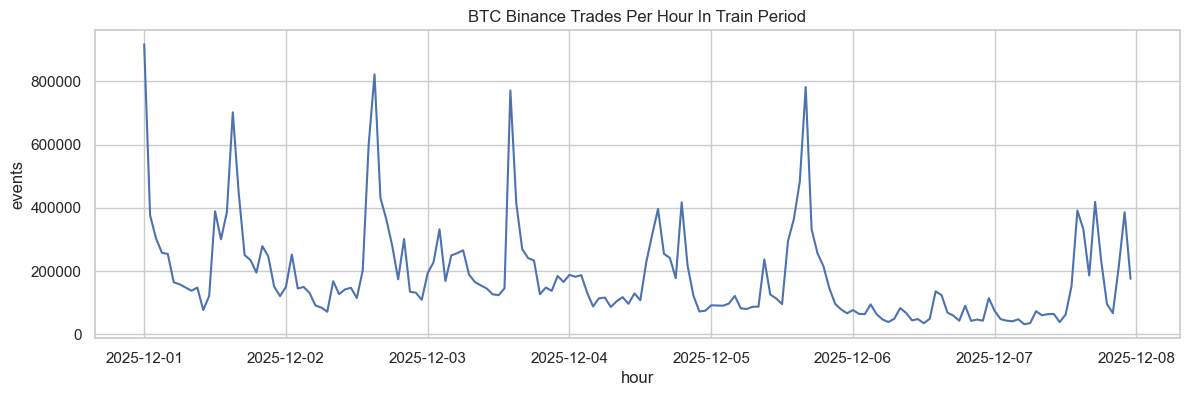

In [5]:
hourly_plot_df = (
    with_datetime(scan_train('trades', 'btcusdt'))
    .with_columns(pl.col('timestamp_dt').dt.truncate('1h').alias('hour'))
    .group_by('hour')
    .agg(pl.len().alias('events'))
    .sort('hour')
    .collect()
    .to_pandas()
)

plt.figure(figsize=(14, 4))
sns.lineplot(data=hourly_plot_df, x='hour', y='events')
plt.title('BTC Binance Trades Per Hour In Train Period')
plt.show()


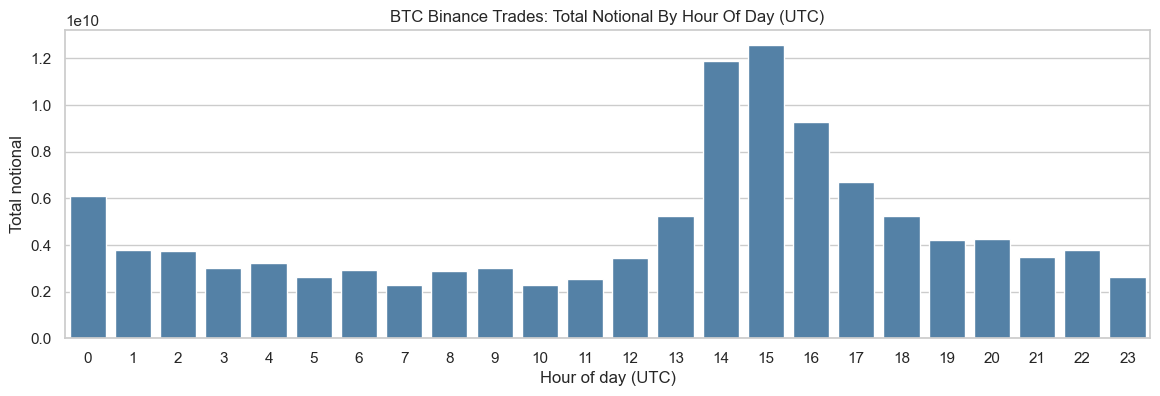

In [6]:
hour_of_day_volume_df = (
    scan_train('trades', 'btcusdt')
    .with_columns([
        pl.from_epoch(pl.col('timestamp'), time_unit='us').alias('timestamp_dt'),
        (pl.col('price') * pl.col('amount')).alias('notional'),
    ])
    .with_columns(pl.col('timestamp_dt').dt.hour().alias('hour_of_day'))
    .group_by('hour_of_day')
    .agg([
        pl.len().alias('trade_count'),
        pl.col('notional').sum().alias('total_notional'),
    ])
    .sort('hour_of_day')
    .collect()
    .to_pandas()
)

plt.figure(figsize=(14, 4))
sns.barplot(data=hour_of_day_volume_df, x='hour_of_day', y='total_notional', color='steelblue')
plt.title('BTC Binance Trades: Total Notional By Hour Of Day (UTC)')
plt.xlabel('Hour of day (UTC)')
plt.ylabel('Total notional')
plt.show()

BTC trading activity is clearly not uniform over time. The hourly series shows repeated bursts rather than a smooth flow, which suggests the market operates in distinct activity regimes instead of a stationary baseline. This is important for the task, because a signal that works during high-activity bursts may behave differently during quieter periods

The intraday notional profile also shows a strong hour-of-day effect. Total traded notional is highest around 14:00-16:00 UTC, while the weakest hours are in the early morning UTC range

## Large Time Gaps

In [7]:
gap_rows = []
for source in SOURCES:
    for symbol in SYMBOLS:
        row = gap_summary(scan_train(source, symbol)).to_dicts()[0]
        row['source'] = source
        row['symbol'] = symbol
        gap_rows.append(row)

gap_df = pd.DataFrame(gap_rows)
gap_df.sort_values(['source', 'symbol']).reset_index(drop=True)

,median_gap_ms,p99_gap_ms,p999_gap_ms,max_gap_ms,gaps_over_1s,gaps_over_10s,source,symbol
0,52.00000,316.00000,578.00000,5245.00000,318,0,bbo,btcusdt
1,52.00000,263.00000,472.00000,3466.00000,103,0,bbo,ethusdt
2,3597.00000,831741.00000,1772760.00000,2741794.00000,10859,3845,liq_binance,btcusdt
3,3941.00000,700436.00000,1572187.00000,2239479.00000,12191,4471,liq_binance,ethusdt
4,84.00000,802606.00000,3186224.00000,13014068.00000,3585,1874,liq_bybit,btcusdt
5,99.00000,1101164.00000,3470405.00000,10965050.00000,3261,1790,liq_bybit,ethusdt
6,0.00000,408.00000,1016.00000,4121.00000,33513,0,trades,btcusdt
7,0.00000,270.00000,787.00000,6778.00000,24746,0,trades,ethusdt


Trades and BBO look like dense continuous streams. Their median gaps are tiny, and even the largest gaps stay within a few seconds, so these sources seem reliable for short-horizon market-state and markout calculations

Liquidations are much more sparse and bursty. The median gap is already far larger than in trades or BBO, and the upper-tail gaps are very wide, with many intervals above 1s and 10s

Bybit liquidation timing looks a bit less regular than Binance, especially in the extreme tail. That suggests cross-exchange liquidation alignment may be noisy and should be checked with flexible windows rather than overly strict exact matching

## Smooth vs Bursty Flow

In [8]:
burst_rows = []
for source in SOURCES:
    for symbol in SYMBOLS:
        row = burstiness_summary(scan_train(source, symbol)).to_dicts()[0]
        row['source'] = source
        row['symbol'] = symbol
        burst_rows.append(row)

burst_df = pd.DataFrame(burst_rows)
burst_df.sort_values('cv_events_per_min', ascending=False).reset_index(drop=True)

,minutes_with_events,mean_events_per_min,std_events_per_min,cv_events_per_min,p50_events_per_min,p90_events_per_min,p99_events_per_min,max_events_per_min,source,symbol
0,1462,9.96648,31.88514,3.19924,2.00000,21.00000,121.00000,559,liq_bybit,ethusdt
1,1520,13.04342,32.38280,2.48269,3.00000,33.00000,170.00000,473,liq_bybit,btcusdt
2,10080,5243.29226,6676.89706,1.27342,3196.00000,11004.00000,33531.00000,124573,trades,ethusdt
3,10080,3088.57679,3547.82524,1.14869,2041.00000,6488.00000,17923.00000,54054,trades,btcusdt
4,3060,3.55523,4.01459,1.12921,2.00000,9.00000,19.00000,36,liq_binance,btcusdt
5,3486,3.50344,3.93919,1.12438,2.00000,8.00000,19.00000,35,liq_binance,ethusdt
6,10080,800.98026,170.07388,0.21233,795.00000,1041.00000,1144.00000,1155,bbo,btcusdt
7,10080,897.89772,159.71728,0.17788,910.00000,1103.00000,1153.00000,1155,bbo,ethusdt


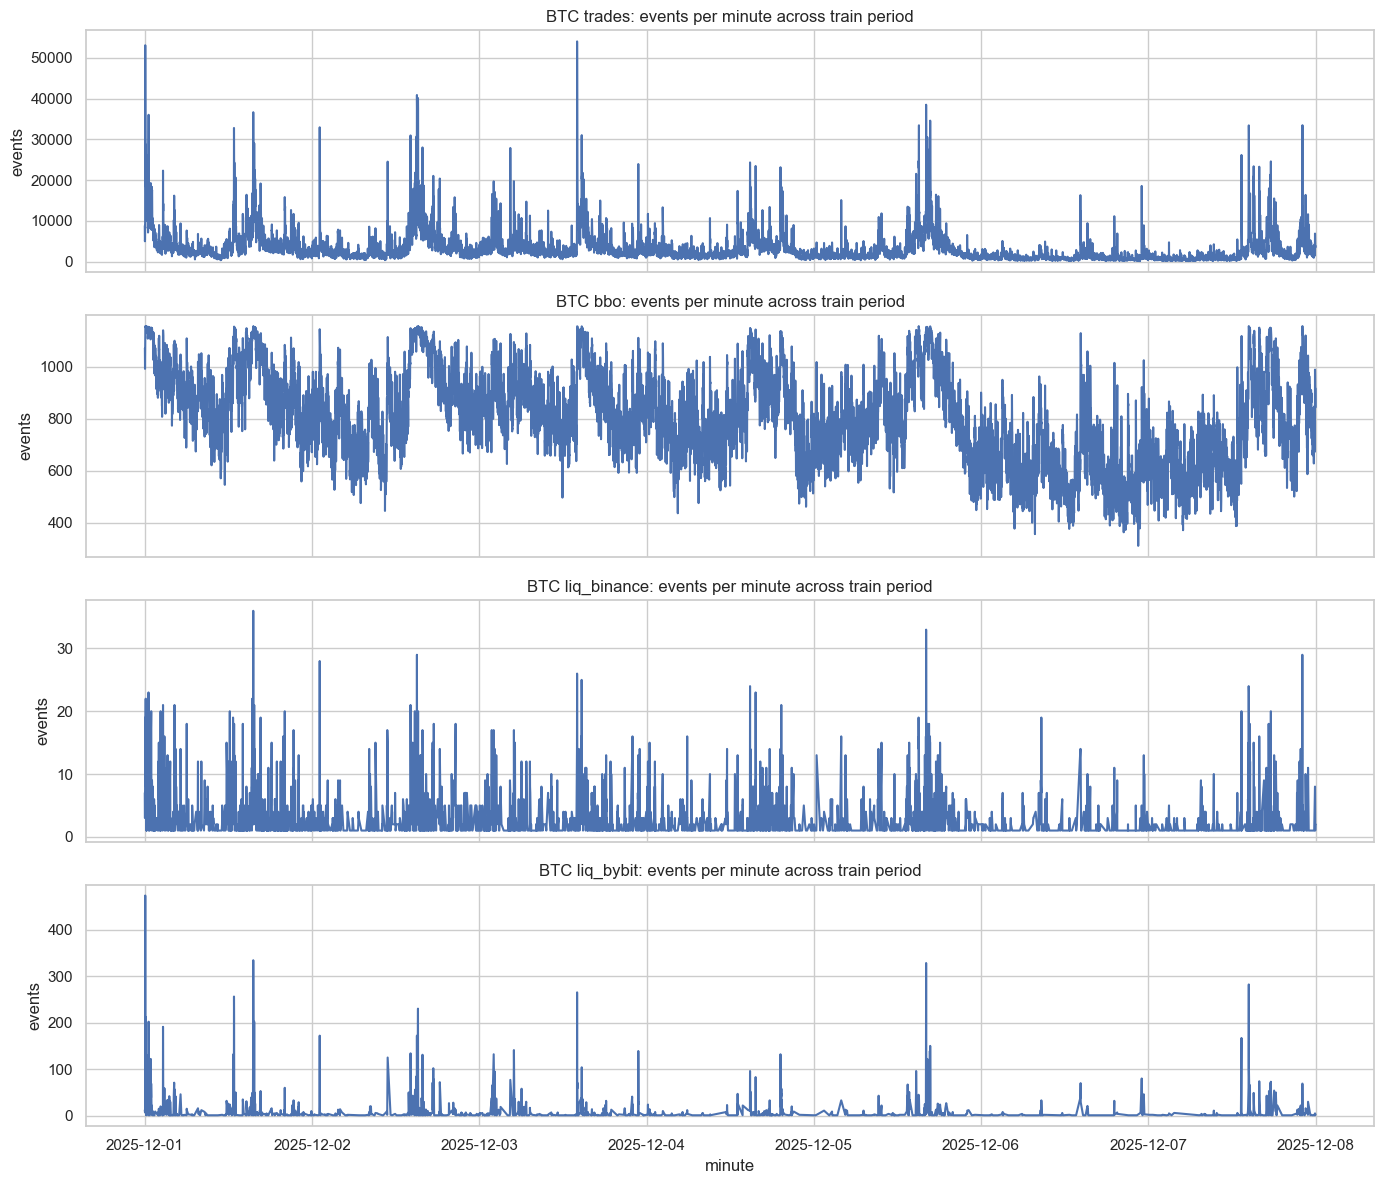

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
for ax, source in zip(axes, SOURCES):
    counts = minute_activity(scan_train(source, 'btcusdt')).to_pandas()
    sns.lineplot(data=counts, x='minute', y='events', ax=ax)
    ax.set_title(f'BTC {source}: events per minute across train period')
plt.tight_layout()
plt.show()

The flow is clearly uneven. BBO looks fairly stable minute to minute, but trades already come in waves, and liquidation streams are much more bursty

For BTC, regular trading activity rises and falls throughout the week, with several sharp spikes. Binance liquidations are sparse, but Bybit is even more irregular and concentrated in short bursts, so liquidation data looks more like stress-event activity than a steady background signal

## Day vs Night Activity

In [10]:
day_night_rows = []
for source in SOURCES:
    for symbol in SYMBOLS:
        row = day_night_summary(scan_train(source, symbol)).to_dicts()[0]
        row['source'] = source
        row['symbol'] = symbol
        day_night_rows.append(row)

day_night_df = pd.DataFrame(day_night_rows)
day_night_df.sort_values(['source', 'symbol']).reset_index(drop=True)

,total_events,day_events,night_events,day_share,night_share,avg_events_per_day_hour,avg_events_per_night_hour,source,symbol
0,8073881,4217626,3856255,0.52238,0.47762,351468.83333,321354.58333,bbo,btcusdt
1,9050809,4731878,4318931,0.52281,0.47719,394323.16667,359910.91667,bbo,ethusdt
2,10879,6493,4386,0.59684,0.40316,541.08333,365.50000,liq_binance,btcusdt
3,12213,7394,4819,0.60542,0.39458,616.16667,401.58333,liq_binance,ethusdt
4,19826,12379,7447,0.62438,0.37562,1031.58333,620.58333,liq_bybit,btcusdt
5,14571,9561,5010,0.65617,0.34383,796.75000,417.50000,liq_bybit,ethusdt
6,31132854,18798545,12334309,0.60382,0.39618,1566545.41667,1027859.08333,trades,btcusdt
7,52852386,32731629,20120757,0.61930,0.38070,2727635.75000,1676729.75000,trades,ethusdt


Activity is higher during the day across all sources, but the effect is much stronger for trades and liquidations than for BBO. Quotes are fairly balanced between day and night, while actual trading and liquidation activity is much more concentrated in daytime hours

## Distributions

In [11]:
trade_btc = with_trade_fields(scan_train('trades', 'btcusdt'))
trade_eth = with_trade_fields(scan_train('trades', 'ethusdt'))
bbo_btc = with_bbo_fields(scan_train('bbo', 'btcusdt'))
bbo_eth = with_bbo_fields(scan_train('bbo', 'ethusdt'))
liq_binance_btc = with_liq_fields(scan_train('liq_binance', 'btcusdt'))
liq_binance_eth = with_liq_fields(scan_train('liq_binance', 'ethusdt'))
liq_bybit_btc = with_liq_fields(scan_train('liq_bybit', 'btcusdt'))
liq_bybit_eth = with_liq_fields(scan_train('liq_bybit', 'ethusdt'))

In [12]:
trade_btc_describe = (
    trade_btc
    .select(['price', 'amount', 'notional'])
    .collect()
    .describe()
)

trade_eth_describe = (
    trade_eth
    .select(['price', 'amount', 'notional'])
    .collect()
    .describe()
)

display(trade_btc_describe)
display(trade_eth_describe)

display(side_summary(scan_train('trades', 'btcusdt')))
display(side_summary(scan_train('trades', 'ethusdt')))


statistic,price,amount,notional
str,f64,f64,f64
"""count""",3.1132854e7,3.1132854e7,3.1132854e7
"""null_count""",0.0,0.0,0.0
"""mean""",89857.245715,0.039783,3569.149046
"""std""",2663.052801,0.27715,24765.765482
"""min""",83786.0,0.001,83.789
"""25%""",87468.7,0.002,184.789
"""50%""",90096.9,0.003,273.8025
"""75%""",92271.9,0.012,1031.8506
"""max""",94185.0,351.407,2.9869e7


statistic,price,amount,notional
str,f64,f64,f64
"""count""",5.2852386e7,5.2852386e7,5.2852386e7
"""null_count""",0.0,0.0,0.0
"""mean""",3010.322332,0.635631,1913.892759
"""std""",135.81722,5.347659,15988.706691
"""min""",2718.07,0.001,2.71808
"""25%""",2892.75,0.009,27.3966
"""50%""",3035.37,0.021,62.4
"""75%""",3121.13,0.211,637.432
"""max""",3239.27,7827.076,2.1971e7


side,count,share
str,u32,f64
"""buy""",15576038,0.500309
"""sell""",15556816,0.499691


side,count,share
str,u32,f64
"""buy""",26429636,0.500065
"""sell""",26422750,0.499935


In [13]:
bbo_btc_describe = (
    bbo_btc
    .select(['bid_price', 'ask_price', 'spread', 'spread_bps', 'mid', 'bid_amount', 'ask_amount'])
    .collect()
    .describe()
)

bbo_eth_describe = (
    bbo_eth
    .select(['bid_price', 'ask_price', 'spread', 'spread_bps', 'mid', 'bid_amount', 'ask_amount'])
    .collect()
    .describe()
)

display(bbo_btc_describe)
display(bbo_eth_describe)


statistic,bid_price,ask_price,spread,spread_bps,mid,bid_amount,ask_amount
str,f64,f64,f64,f64,f64,f64,f64
"""count""",8.073881e6,8.073881e6,8.073881e6,8.073881e6,8.073881e6,8.073881e6,8.073881e6
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",90036.019538,90036.133945,0.114407,0.01272,90036.076742,6.467938,6.354519
"""std""",2547.248556,2547.247726,0.379928,0.042154,2547.248134,6.684872,7.551163
"""min""",83789.4,83789.5,0.1,0.010622,83789.45,0.001,0.001
"""25%""",88461.9,88462.3,0.1,0.010831,88462.05,2.384,2.307
"""50%""",89859.8,89859.9,0.1,0.011136,89859.85,4.932,4.769
"""75%""",92340.9,92341.0,0.1,0.011344,92340.95,9.099,8.815
"""max""",94146.3,94147.6,249.5,26.748789,94146.95,943.017,875.287


statistic,bid_price,ask_price,spread,spread_bps,mid,bid_amount,ask_amount
str,f64,f64,f64,f64,f64,f64,f64
"""count""",9.050809e6,9.050809e6,9.050809e6,9.050809e6,9.050809e6,9.050809e6,9.050809e6
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",3016.36211,3016.372988,0.010878,0.036148,3016.367549,72.356865,71.985942
"""std""",134.478087,134.478003,0.027915,0.093798,134.478044,122.919075,134.54208
"""min""",2718.08,2718.09,0.01,0.030871,2718.085,0.001,0.001
"""25%""",2936.71,2936.74,0.01,0.031988,2936.715,20.83,20.248
"""50%""",3037.75,3037.76,0.01,0.032924,3037.755,49.784,49.222
"""75%""",3126.58,3126.59,0.01,0.034648,3126.585,99.474,97.287
"""max""",3239.26,3239.27,34.9,119.053711,3239.265,10000.474,10708.075


In [14]:
liq_binance_btc_describe = (
    liq_binance_btc
    .select(['price', 'amount', 'notional'])
    .collect()
    .describe()
)

liq_bybit_btc_describe = (
    liq_bybit_btc
    .select(['price', 'amount', 'notional'])
    .collect()
    .describe()
)

display(liq_binance_btc_describe)
display(liq_bybit_btc_describe)
display(side_summary(scan_train('liq_binance', 'btcusdt')))
display(side_summary(scan_train('liq_bybit', 'btcusdt')))


statistic,price,amount,notional
str,f64,f64,f64
"""count""",10879.0,10879.0,10879.0
"""null_count""",0.0,0.0,0.0
"""mean""",89610.664126,0.117256,10503.978973
"""std""",2904.845199,0.875615,78417.802422
"""min""",83473.8,0.001,83.4778
"""25%""",87152.5,0.004,371.2032
"""50%""",89838.1,0.013,1169.0084
"""75%""",92006.7,0.05,4445.4072
"""max""",177134.7,63.124,5.6095e6


statistic,price,amount,notional
str,f64,f64,f64
"""count""",19826.0,19826.0,19826.0
"""null_count""",0.0,0.0,0.0
"""mean""",89069.736765,0.146359,13043.282597
"""std""",2793.393994,0.906592,80982.515063
"""min""",83371.8,0.001,83.381
"""25%""",87075.6,0.004,351.2672
"""50%""",89043.7,0.013,1191.2602
"""75%""",91272.5,0.053,4731.3774
"""max""",94609.7,23.535,2.0273e6


side,count,share
str,u32,f64
"""sell""",5892,0.541594
"""buy""",4987,0.458406


side,count,share
str,u32,f64
"""sell""",12428,0.626854
"""buy""",7398,0.373146


Trade sizes are very skewed on both symbols. The median BTC trade is only about 0.003 BTC and the median ETH trade is about 0.021 ETH, while the mean is much larger, so the flow is dominated by many small trades and a much smaller number of very large ones

The same pattern shows up even more strongly in trade notional. For BTC, median trade notional is only around 274 USD, but the maximum is almost 30M USD; for ETH, the median is about 62 USD, while the maximum is above 21M USD. That is a clear heavy-tail structure and a good reminder that averages alone can be misleading here

The order book itself looks much more stable than trades. For BTC, the spread is almost always 0.1, and for ETH it is almost always 0.01, so most of the time the market is quoted very tightly. Still, there are rare extreme spread spikes, which likely correspond to stressed moments and may be useful as a regime feature

Liquidations are much larger than ordinary trades in typical size. Median Binance BTC liquidation notional is around 1.17k USD, and median Bybit BTC liquidation notional is around 1.19k USD, but both series also have very large outliers

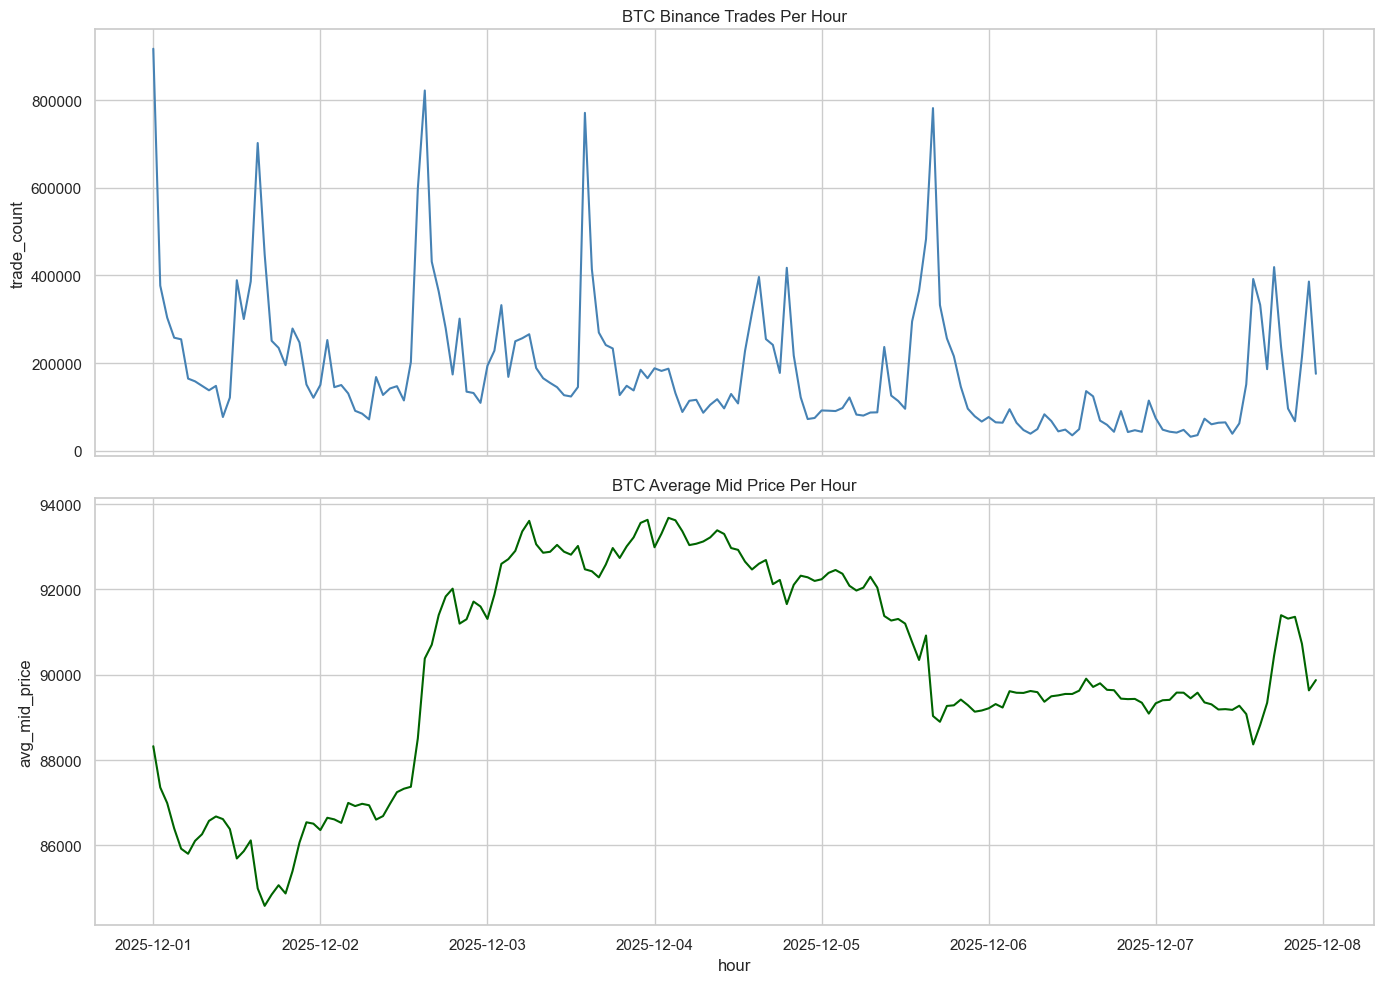

In [15]:
trade_hourly_df = (
    with_datetime(scan_train('trades', 'btcusdt'))
    .with_columns(pl.col('timestamp_dt').dt.truncate('1h').alias('hour'))
    .group_by('hour')
    .agg(pl.len().alias('trade_count'))
    .sort('hour')
    .collect()
    .to_pandas()
)

price_hourly_df = (
    with_bbo_fields(scan_train('bbo', 'btcusdt'))
    .pipe(with_datetime)
    .with_columns(pl.col('timestamp_dt').dt.truncate('1h').alias('hour'))
    .group_by('hour')
    .agg(pl.col('mid').mean().alias('avg_mid_price'))
    .sort('hour')
    .collect()
    .to_pandas()
)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

sns.lineplot(data=trade_hourly_df, x='hour', y='trade_count', ax=axes[0], color='steelblue')
axes[0].set_title('BTC Binance Trades Per Hour')
axes[0].set_ylabel('trade_count')

sns.lineplot(data=price_hourly_df, x='hour', y='avg_mid_price', ax=axes[1], color='darkgreen')
axes[1].set_title('BTC Average Mid Price Per Hour')
axes[1].set_ylabel('avg_mid_price')
plt.tight_layout()
plt.show()


In [16]:
btc_spread_sample = sample_for_plot(bbo_btc, 'spread_bps', max_rows=500_000).clip(lower=0)
spread_bins = [-0.001, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.50, 1.00, float('inf')]
spread_labels = [
    '[0, 0.005)',
    '[0.005, 0.01)',
    '[0.01, 0.02)',
    '[0.02, 0.05)',
    '[0.05, 0.10)',
    '[0.10, 0.20)',
    '[0.20, 0.50)',
    '[0.50, 1.00)',
    '[1.00, inf)'
]
spread_bucket_df = bucket_counts(btc_spread_sample, spread_bins, spread_labels)
display(spread_bucket_df)

,bucket,count,share
0,"[0, 0.005)",0,0.00000
1,"[0.005, 0.01)",0,0.00000
2,"[0.01, 0.02)",491007,0.98201
3,"[0.02, 0.05)",3347,0.00669
4,"[0.05, 0.10)",1758,0.00352
5,"[0.10, 0.20)",1600,0.00320
6,"[0.20, 0.50)",1462,0.00292
7,"[0.50, 1.00)",564,0.00113
8,"[1.00, inf)",262,0.00052


BTC spread is extremely tight most of the time. About 98.2% of observations fall into the 0.01–0.02 bps range, so the normal quoting regime is very stable and very liquid

The wider spread buckets are rare, but they do exist. That means extreme spread values are more likely to represent short stress episodes than normal market conditions, so spread looks more useful as a regime or stress flag than as a continuously varying feature

## Exchange Comparison

1. Plot hourly liquidation volume for Binance and Bybit
2. Determine which exchange has the higher liquidation frequency

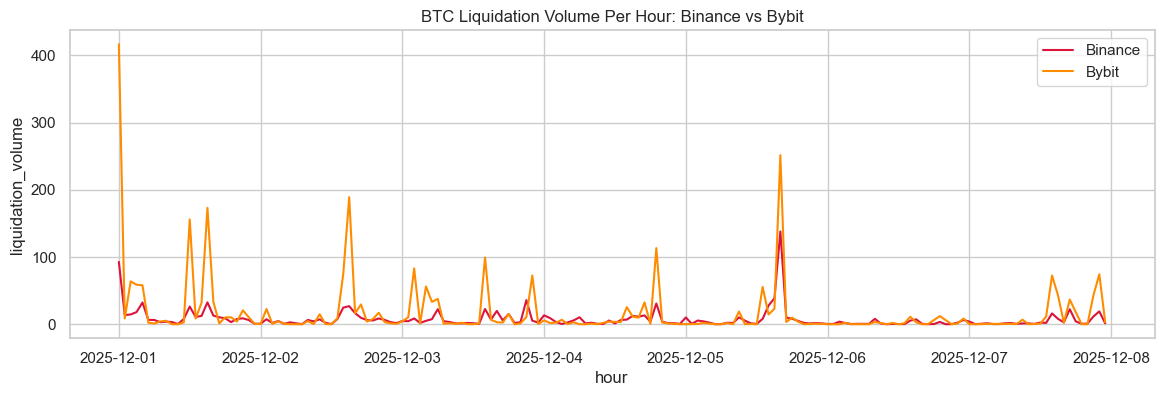

In [17]:
binance_liq_hourly_compare_df = (
    scan_train('liq_binance', 'btcusdt')
    .pipe(with_datetime)
    .with_columns(pl.col('timestamp_dt').dt.truncate('1h').alias('hour'))
    .group_by('hour')
    .agg([
        pl.col('amount').sum().alias('binance_liq_volume'),
        pl.len().alias('binance_liq_count'),
    ])
    .sort('hour')
    .collect()
    .to_pandas()
)

bybit_liq_hourly_compare_df = (
    scan_train('liq_bybit', 'btcusdt')
    .pipe(with_datetime)
    .with_columns(pl.col('timestamp_dt').dt.truncate('1h').alias('hour'))
    .group_by('hour')
    .agg([
        pl.col('amount').sum().alias('bybit_liq_volume'),
        pl.len().alias('bybit_liq_count'),
    ])
    .sort('hour')
    .collect()
    .to_pandas()
)

plt.figure(figsize=(14, 4))
sns.lineplot(data=binance_liq_hourly_compare_df, x='hour', y='binance_liq_volume', label='Binance', color='crimson')
sns.lineplot(data=bybit_liq_hourly_compare_df, x='hour', y='bybit_liq_volume', label='Bybit', color='darkorange')
plt.title('BTC Liquidation Volume Per Hour: Binance vs Bybit')
plt.ylabel('liquidation_volume')
plt.show()

In [18]:
exchange_frequency_compare = pd.DataFrame([
    {
        'exchange': 'Binance',
        'total_liquidation_events': int(scan_train('liq_binance', 'btcusdt').select(pl.len()).collect().item()),
        'avg_events_per_hour': float(binance_liq_hourly_compare_df['binance_liq_count'].mean()),
        'median_events_per_hour': float(binance_liq_hourly_compare_df['binance_liq_count'].median()),
        'max_events_per_hour': int(binance_liq_hourly_compare_df['binance_liq_count'].max()),
        'total_liquidation_volume': float(binance_liq_hourly_compare_df['binance_liq_volume'].sum()),
    },
    {
        'exchange': 'Bybit',
        'total_liquidation_events': int(scan_train('liq_bybit', 'btcusdt').select(pl.len()).collect().item()),
        'avg_events_per_hour': float(bybit_liq_hourly_compare_df['bybit_liq_count'].mean()),
        'median_events_per_hour': float(bybit_liq_hourly_compare_df['bybit_liq_count'].median()),
        'max_events_per_hour': int(bybit_liq_hourly_compare_df['bybit_liq_count'].max()),
        'total_liquidation_volume': float(bybit_liq_hourly_compare_df['bybit_liq_volume'].sum()),
    },
])

exchange_frequency_compare

,exchange,total_liquidation_events,avg_events_per_hour,median_events_per_hour,max_events_per_hour,total_liquidation_volume
0,Binance,10879,64.75595,42.00000,527,1275.62500
1,Bybit,19826,125.48101,32.50000,2570,2901.72300


Bybit has noticeably more BTC liquidation activity than Binance in this sample. It has almost twice as many events, higher average hourly activity, and a much larger total liquidation volume

At the same time, the flow on Bybit is less even. The median hourly count is not that far from Binance, but the hourly spikes are much larger, which means a big part of the difference comes from short stress bursts rather than from a steady increase throughout the week

## Compare total liquidation notional across exchanges

`liq_notional = price * amount`

This shows where liquidations are larger in USD terms.


In [19]:
exchange_notional_compare = pd.DataFrame([
    {
        'exchange': 'Binance',
        'total_liquidation_notional': float(
            with_liq_fields(scan_train('liq_binance', 'btcusdt'))
            .select(pl.col('notional').sum())
            .collect()
            .item()
        ),
    },
    {
        'exchange': 'Bybit',
        'total_liquidation_notional': float(
            with_liq_fields(scan_train('liq_bybit', 'btcusdt'))
            .select(pl.col('notional').sum())
            .collect()
            .item()
        ),
    },
])

exchange_notional_compare

,exchange,total_liquidation_notional
0,Binance,114272787.25217
1,Bybit,258596120.77250


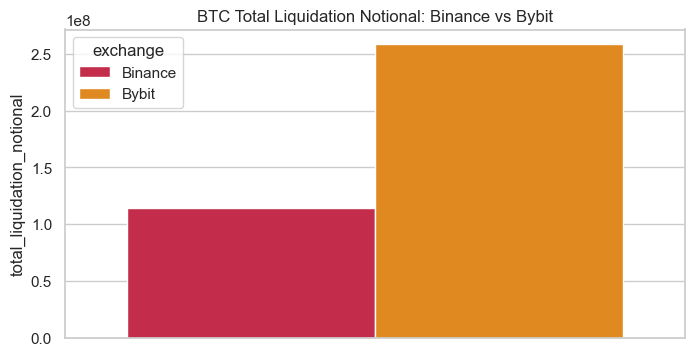

In [20]:
plt.figure(figsize=(8, 4))
sns.barplot(data=exchange_notional_compare, hue='exchange', y='total_liquidation_notional', palette=['crimson', 'darkorange'])
plt.title('BTC Total Liquidation Notional: Binance vs Bybit')
plt.ylabel('total_liquidation_notional')
plt.show()

Bybit dominates in dollar terms, not just in event count. Over these seven days, total BTC liquidation notional on Bybit is a bit more than twice the Binance number, so the larger role of Bybit is visible both in frequency and in total size

That makes Bybit liquidations especially interesting as a candidate signal source. If liquidation-driven stress really matters for future maker PnL, Bybit may carry more information simply because more of that stress shows up there

## Compare liquidation side balance

Compare `buy liquidation volume` vs `sell liquidation volume`.

If buy liquidation volume is much larger, that can indicate stronger upward pressure. If sell liquidation volume is larger, that can indicate stronger downward pressure.


In [21]:
side_balance_compare = pd.concat([
    with_liq_fields(scan_train('liq_binance', 'btcusdt'))
        .group_by('side')
        .agg([
            pl.col('amount').sum().alias('liquidation_volume'),
            pl.col('notional').sum().alias('liquidation_notional'),
            pl.len().alias('event_count'),
        ])
        .with_columns(pl.lit('Binance').alias('exchange'))
        .collect()
        .to_pandas(),
    with_liq_fields(scan_train('liq_bybit', 'btcusdt'))
        .group_by('side')
        .agg([
            pl.col('amount').sum().alias('liquidation_volume'),
            pl.col('notional').sum().alias('liquidation_notional'),
            pl.len().alias('event_count'),
        ])
        .with_columns(pl.lit('Bybit').alias('exchange'))
        .collect()
        .to_pandas(),
], ignore_index=True)

side_balance_compare

,side,liquidation_volume,liquidation_notional,event_count,exchange
0,buy,551.95800,50095840.85929,4987,Binance
1,sell,723.66700,64176946.39288,5892,Binance
2,sell,1824.83900,160485069.54860,12428,Bybit
3,buy,1076.88400,98111051.22390,7398,Bybit


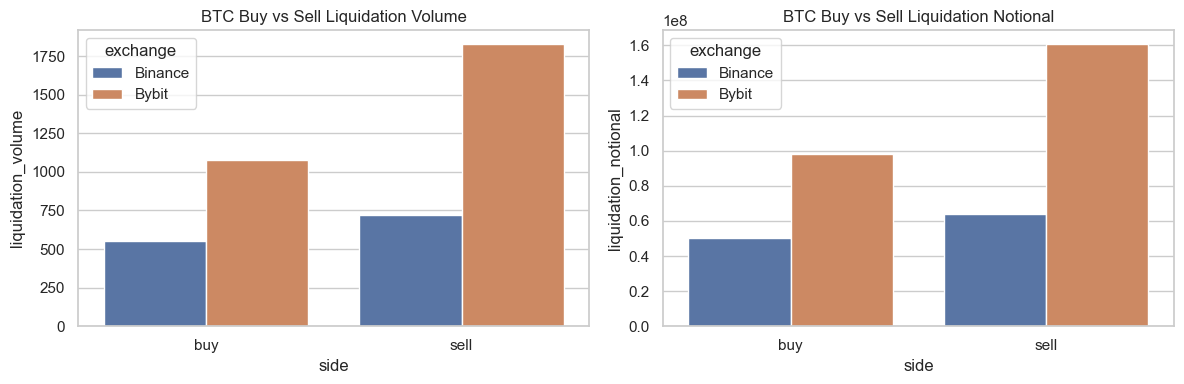

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=side_balance_compare, x='side', y='liquidation_volume', hue='exchange', ax=axes[0])
axes[0].set_title('BTC Buy vs Sell Liquidation Volume')
axes[0].set_ylabel('liquidation_volume')

sns.barplot(data=side_balance_compare, x='side', y='liquidation_notional', hue='exchange', ax=axes[1])
axes[1].set_title('BTC Buy vs Sell Liquidation Notional')
axes[1].set_ylabel('liquidation_notional')

plt.tight_layout()
plt.show()

On both exchanges, sell liquidations are larger than buy liquidations over this period. The imbalance is visible on Binance, but it is much stronger on Bybit, where both the event count and the total notional are clearly tilted toward the sell side

So the liquidation flow is not side-balanced here. At least in this sample, downside stress looks stronger than upside stress, especially on Bybit, which may matter if sell-side liquidation clusters turn out to be more informative for future maker toxicity

## Cross-Exchange Liquidation Synchrony

For each Bybit liquidation, check whether there is a nearby Binance liquidation on the same symbol.

We measure synchrony using three windows:
- `1s`
- `5s`
- `30s`

Because Bybit timestamps are already shifted by `+200ms` at load time, all comparisons below use the shifted Bybit event time.


In [23]:
def nearest_liquidation_match(symbol: str) -> pl.DataFrame:
    bybit = (
        scan_train('liq_bybit', symbol)
        .select([
            pl.col('timestamp').alias('bybit_ts'),
            pl.col('side').alias('bybit_side'),
            pl.col('price').alias('bybit_price'),
            pl.col('amount').alias('bybit_amount'),
        ])
        .sort('bybit_ts')
    )

    binance = (
        scan_train('liq_binance', symbol)
        .select([
            pl.col('timestamp').alias('binance_ts'),
            pl.col('side').alias('binance_side'),
            pl.col('price').alias('binance_price'),
            pl.col('amount').alias('binance_amount'),
        ])
        .sort('binance_ts')
    )

    backward = bybit.join_asof(
        binance,
        left_on='bybit_ts',
        right_on='binance_ts',
        strategy='backward'
    ).rename({
        'binance_ts': 'binance_ts_back',
        'binance_side': 'binance_side_back',
        'binance_price': 'binance_price_back',
        'binance_amount': 'binance_amount_back',
    })

    forward = bybit.join_asof(
        binance,
        left_on='bybit_ts',
        right_on='binance_ts',
        strategy='forward'
    ).rename({
        'binance_ts': 'binance_ts_fwd',
        'binance_side': 'binance_side_fwd',
        'binance_price': 'binance_price_fwd',
        'binance_amount': 'binance_amount_fwd',
    })

    matched = (
        backward.join(
            forward.select([
                'bybit_ts', 'binance_ts_fwd', 'binance_side_fwd', 'binance_price_fwd', 'binance_amount_fwd'
            ]),
            on='bybit_ts',
            how='left'
        )
        .with_columns([
            (pl.col('bybit_ts') - pl.col('binance_ts_back')).abs().alias('diff_back_us'),
            (pl.col('binance_ts_fwd') - pl.col('bybit_ts')).abs().alias('diff_fwd_us'),
        ])
        .with_columns([
            pl.min_horizontal('diff_back_us', 'diff_fwd_us').alias('nearest_diff_us')
        ])
        .with_columns([
            (pl.col('nearest_diff_us') / 1_000.0).alias('nearest_diff_ms'),
            (pl.col('nearest_diff_us') <= 1_000_000).alias('within_1s'),
            (pl.col('nearest_diff_us') <= 5_000_000).alias('within_5s'),
            (pl.col('nearest_diff_us') <= 30_000_000).alias('within_30s'),
            pl.lit(symbol).alias('symbol'),
        ])
        .with_columns([
            pl.when(pl.col('diff_back_us') <= pl.col('diff_fwd_us'))
              .then(pl.col('binance_ts_back'))
              .otherwise(pl.col('binance_ts_fwd'))
              .alias('nearest_binance_ts'),
            pl.when(pl.col('diff_back_us') <= pl.col('diff_fwd_us'))
              .then(pl.col('binance_side_back'))
              .otherwise(pl.col('binance_side_fwd'))
              .alias('nearest_binance_side'),
        ])
    )

    return matched.collect()


In [24]:
sync_btc = nearest_liquidation_match('btcusdt')
sync_eth = nearest_liquidation_match('ethusdt')

In [25]:
def synchrony_summary(df: pl.DataFrame) -> pl.DataFrame:
    return df.select([
        pl.col('symbol').first().alias('symbol'),
        pl.len().alias('total_bybit_liquidations'),
        pl.col('within_1s').mean().alias('share_within_1s'),
        pl.col('within_5s').mean().alias('share_within_5s'),
        pl.col('within_30s').mean().alias('share_within_30s'),
        pl.col('nearest_diff_ms').median().alias('median_nearest_diff_ms'),
        pl.col('nearest_diff_ms').quantile(0.90).alias('p90_nearest_diff_ms'),
        pl.col('nearest_diff_ms').quantile(0.99).alias('p99_nearest_diff_ms'),
    ])

synchrony_df = pl.concat([synchrony_summary(sync_btc), synchrony_summary(sync_eth)]).to_pandas()
synchrony_df

,symbol,total_bybit_liquidations,share_within_1s,share_within_5s,share_within_30s,median_nearest_diff_ms,p90_nearest_diff_ms,p99_nearest_diff_ms
0,btcusdt,20514,0.89597,0.97080,0.98820,344.00000,1030.00000,41431.00000
1,ethusdt,14997,0.90591,0.96999,0.99000,328.00000,952.00000,29494.00000


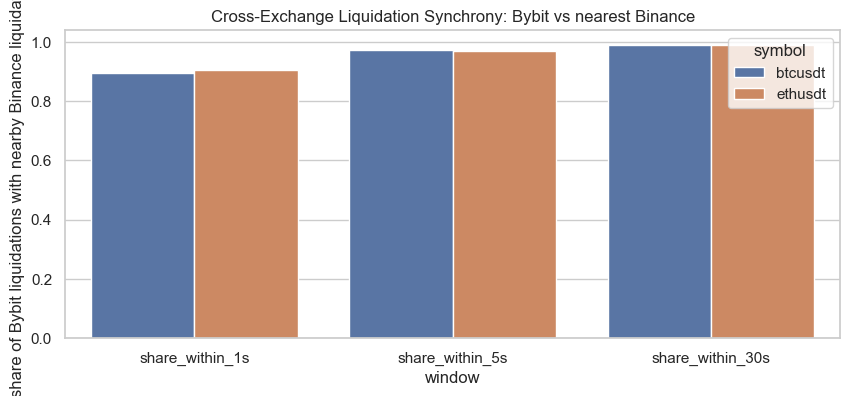

In [26]:
sync_plot_df = synchrony_df.melt(
    id_vars='symbol',
    value_vars=['share_within_1s', 'share_within_5s', 'share_within_30s'],
    var_name='window',
    value_name='share'
)

plt.figure(figsize=(10, 4))
sns.barplot(data=sync_plot_df, x='window', y='share', hue='symbol')
plt.title('Cross-Exchange Liquidation Synchrony: Bybit vs nearest Binance')
plt.ylabel('share of Bybit liquidations with nearby Binance liquidation')
plt.show()

In [27]:
same_side_sync = pl.concat([sync_btc, sync_eth]).with_columns(
    (pl.col('bybit_side') == pl.col('nearest_binance_side')).alias('same_side_nearest')
)

same_side_summary = same_side_sync.group_by('symbol').agg([
    pl.len().alias('total_bybit_liquidations'),
    pl.col('same_side_nearest').mean().alias('share_same_side_nearest'),
    ((pl.col('within_1s')) & (pl.col('same_side_nearest'))).mean().alias('share_same_side_within_1s'),
    ((pl.col('within_5s')) & (pl.col('same_side_nearest'))).mean().alias('share_same_side_within_5s'),
    ((pl.col('within_30s')) & (pl.col('same_side_nearest'))).mean().alias('share_same_side_within_30s'),
]).sort('symbol').to_pandas()

same_side_summary

,symbol,total_bybit_liquidations,share_same_side_nearest,share_same_side_within_1s,share_same_side_within_5s,share_same_side_within_30s
0,btcusdt,20514,0.98411,0.88914,0.96105,0.97606
1,ethusdt,14997,0.98026,0.89518,0.95686,0.97373


Liquidations on the two exchanges are highly synchronized in time. For both BTC and ETH, around 90% of Bybit liquidations have a nearby Binance liquidation within 1s, and almost all of them have one within 5s or 30s

## Binance Mid-Price Reaction To Binance vs Bybit Liquidations

Compare the Binance mid-price response to liquidation events coming from:
- Binance liquidations
- Bybit liquidations

And do it separately for:
- `buy` liquidations
- `sell` liquidations

For each event at time `t`, compute:

`?mid_tau = mid(t + tau) - mid(t)`

for `tau in {1s, 5s, 30s, 120s}`.


In [28]:
REACTION_SYMBOL = 'btcusdt'
REACTION_TOP_N = 500
REACTION_HORIZONS_S = [1, 5, 30, 120]

reaction_bbo = (
    with_bbo_fields(scan_train('bbo', REACTION_SYMBOL))
    .select(['timestamp', 'mid', 'spread_bps'])
    .sort('timestamp')
    .collect()
    .to_pandas()
)

reaction_binance_liq = (
    with_liq_fields(scan_train('liq_binance', REACTION_SYMBOL))
    .collect()
    .to_pandas()
)
reaction_bybit_liq = (
    with_liq_fields(scan_train('liq_bybit', REACTION_SYMBOL))
    .collect()
    .to_pandas()
)

reaction_binance_top_buy = reaction_binance_liq[reaction_binance_liq['side'] == 'buy'].nlargest(REACTION_TOP_N, 'notional').sort_values('timestamp').reset_index(drop=True)
reaction_binance_top_sell = reaction_binance_liq[reaction_binance_liq['side'] == 'sell'].nlargest(REACTION_TOP_N, 'notional').sort_values('timestamp').reset_index(drop=True)
reaction_bybit_top_buy = reaction_bybit_liq[reaction_bybit_liq['side'] == 'buy'].nlargest(REACTION_TOP_N, 'notional').sort_values('timestamp').reset_index(drop=True)
reaction_bybit_top_sell = reaction_bybit_liq[reaction_bybit_liq['side'] == 'sell'].nlargest(REACTION_TOP_N, 'notional').sort_values('timestamp').reset_index(drop=True)

reaction_bbo = reaction_bbo.sort_values('timestamp').reset_index(drop=True)

print(len(reaction_binance_top_buy), len(reaction_binance_top_sell), len(reaction_bybit_top_buy), len(reaction_bybit_top_sell))

500 500 500 500


In [29]:
def attach_event_mid_response(events: pd.DataFrame, bbo: pd.DataFrame, horizons_s: list[int], event_source: str, event_side: str) -> pd.DataFrame:
    out = events[['timestamp', 'side', 'price', 'amount', 'notional']].copy()
    out['event_source'] = event_source
    out['event_side_group'] = event_side

    base = pd.merge_asof(
        out[['timestamp']].sort_values('timestamp'),
        bbo[['timestamp', 'mid']].sort_values('timestamp'),
        on='timestamp',
        direction='backward',
        allow_exact_matches=True,
    )
    out = out.sort_values('timestamp').reset_index(drop=True)
    out['mid_t'] = base['mid'].to_numpy()

    for tau in horizons_s:
        target = out[['timestamp']].copy()
        target['target_ts'] = target['timestamp'] + tau * 1_000_000
        future = pd.merge_asof(
            target.sort_values('target_ts'),
            bbo[['timestamp', 'mid']].sort_values('timestamp'),
            left_on='target_ts',
            right_on='timestamp',
            direction='backward',
            allow_exact_matches=True,
        )
        out[f'mid_t_plus_{tau}s'] = future['mid'].to_numpy()
        out[f'delta_mid_{tau}s'] = out[f'mid_t_plus_{tau}s'] - out['mid_t']
        out[f'delta_mid_bps_{tau}s'] = (out[f'delta_mid_{tau}s'] / out['mid_t']) * 10_000.0

    return out

mid_reaction_frames = [
    attach_event_mid_response(reaction_binance_top_buy, reaction_bbo, REACTION_HORIZONS_S, 'binance_liq', 'buy'),
    attach_event_mid_response(reaction_binance_top_sell, reaction_bbo, REACTION_HORIZONS_S, 'binance_liq', 'sell'),
    attach_event_mid_response(reaction_bybit_top_buy, reaction_bbo, REACTION_HORIZONS_S, 'bybit_liq', 'buy'),
    attach_event_mid_response(reaction_bybit_top_sell, reaction_bbo, REACTION_HORIZONS_S, 'bybit_liq', 'sell'),
]
mid_reaction_all = pd.concat(mid_reaction_frames, ignore_index=True)
mid_reaction_all.head()

,timestamp,side,price,amount,notional,event_source,event_side_group,mid_t,mid_t_plus_1s,delta_mid_1s,delta_mid_bps_1s,mid_t_plus_5s,delta_mid_5s,delta_mid_bps_5s,mid_t_plus_30s,delta_mid_30s,delta_mid_bps_30s,mid_t_plus_120s,delta_mid_120s,delta_mid_bps_120s
0,1764548328610000,buy,89177.70000,1.68900,150621.13530,binance_liq,buy,88825.65000,88818.45000,-7.20000,-0.81058,88830.05000,4.40000,0.49535,88604.95000,-220.70000,-24.84643,88689.35000,-136.30000,-15.34467
1,1764549376714000,buy,88251.40000,0.79200,69895.10880,binance_liq,buy,87959.55000,87933.85000,-25.70000,-2.92180,87907.80000,-51.75000,-5.88339,87946.85000,-12.70000,-1.44385,87874.25000,-85.30000,-9.69764
2,1764549706207000,buy,88401.40000,3.03800,268563.45320,binance_liq,buy,88062.15000,88087.95000,25.80000,2.92975,88140.05000,77.90000,8.84603,88051.15000,-11.00000,-1.24912,87809.45000,-252.70000,-28.69564
3,1764550626660000,buy,87553.80000,0.67600,59186.36880,binance_liq,buy,87210.85000,87225.85000,15.00000,1.71997,87220.15000,9.30000,1.06638,87127.05000,-83.80000,-9.60890,87069.85000,-141.00000,-16.16771
4,1764551008364000,buy,87889.10000,0.23500,20653.93850,binance_liq,buy,87538.25000,87538.25000,0.00000,0.00000,87521.05000,-17.20000,-1.96486,87344.15000,-194.10000,-22.17316,87387.65000,-150.60000,-17.20391


In [30]:
mid_reaction_summary_rows = []
for event_source in ['binance_liq', 'bybit_liq']:
    for event_side in ['buy', 'sell']:
        sub = mid_reaction_all[(mid_reaction_all['event_source'] == event_source) & (mid_reaction_all['event_side_group'] == event_side)]
        row = {'event_source': event_source, 'event_side': event_side, 'event_count': len(sub)}
        for tau in REACTION_HORIZONS_S:
            row[f'mean_delta_mid_bps_{tau}s'] = sub[f'delta_mid_bps_{tau}s'].mean()
            row[f'median_delta_mid_bps_{tau}s'] = sub[f'delta_mid_bps_{tau}s'].median()
        mid_reaction_summary_rows.append(row)

mid_reaction_summary = pd.DataFrame(mid_reaction_summary_rows)
mid_reaction_summary

,event_source,event_side,event_count,mean_delta_mid_bps_1s,median_delta_mid_bps_1s,mean_delta_mid_bps_5s,median_delta_mid_bps_5s,mean_delta_mid_bps_30s,median_delta_mid_bps_30s,mean_delta_mid_bps_120s,median_delta_mid_bps_120s
0,binance_liq,buy,500,0.10488,0.00000,-0.00818,0.00000,-1.11758,-1.11925,-1.08385,-1.79370
1,binance_liq,sell,500,-0.22381,0.00000,-0.14951,0.00000,-0.25832,0.31238,-1.46144,-0.10744
2,bybit_liq,buy,500,0.20911,0.04359,0.84237,0.38128,-1.02134,-1.18063,-2.55771,-2.68420
3,bybit_liq,sell,500,-0.15776,0.00000,1.63220,0.86743,2.68026,1.75256,-1.43290,-0.93581


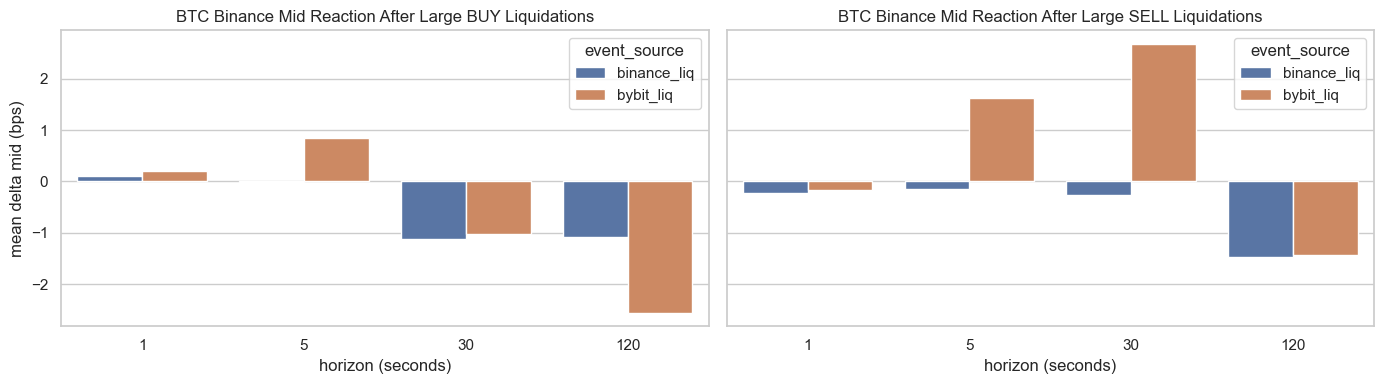

In [31]:
mid_plot_df = pd.DataFrame([
    {'event_source': event_source, 'event_side': event_side, 'horizon_s': tau, 'mean_delta_mid_bps': sub[f'delta_mid_bps_{tau}s'].mean()}
    for event_source in ['binance_liq', 'bybit_liq']
    for event_side in ['buy', 'sell']
    for sub in [mid_reaction_all[(mid_reaction_all['event_source'] == event_source) & (mid_reaction_all['event_side_group'] == event_side)]]
    for tau in REACTION_HORIZONS_S
])

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, side in zip(axes, ['buy', 'sell']):
    sns.barplot(data=mid_plot_df[mid_plot_df['event_side'] == side], x='horizon_s', y='mean_delta_mid_bps', hue='event_source', ax=ax)
    ax.set_title(f'BTC Binance Mid Reaction After Large {side.upper()} Liquidations')
    ax.set_ylabel('mean delta mid (bps)')
    ax.set_xlabel('horizon (seconds)')
plt.tight_layout()
plt.show()

The short-term reaction is small and noisy, but some differences between exchanges do show up. After large buy liquidations, both sources give a small positive move at 1s, and Bybit stays more positive at 5s, although the effect fades and turns negative on longer horizons

The more interesting result is on large sell liquidations. Binance events are mildly negative at short horizons, which is more intuitive, but large Bybit sell liquidations are followed by a positive move at 5s and 30s, so the market often rebounds instead of continuing lower. That suggests the reaction is not purely directional and may depend on whether the event reflects continuation or exhaustion

## Which Exchange Better Predicts Toxic Maker Trades

Compare whether Binance maker PnL deteriorates after large liquidation events from:
- Binance
- Bybit

And do it separately for:
- `buy` liquidations
- `sell` liquidations



In [32]:
PNL_EVENT_WINDOW_S = 1
PNL_HORIZONS_S = [1, 5, 30, 120]

reaction_trades = (
    with_trade_fields(scan_train('trades', REACTION_SYMBOL))
    .collect()
    .to_pandas()
    .sort_values('timestamp')
    .reset_index(drop=True)
)
reaction_trades['maker_sign'] = reaction_trades['side'].map({'buy': 1.0, 'sell': -1.0})
reaction_trades['weight'] = reaction_trades['notional'].clip(upper=100_000.0)


In [33]:
def trades_after_events(events: pd.DataFrame, trades: pd.DataFrame, window_s: int, event_source: str, event_side: str) -> pd.DataFrame:
    pieces = []
    window_us = window_s * 1_000_000
    for _, row in events.iterrows():
        event_ts = row['timestamp']
        sub = trades[(trades['timestamp'] >= event_ts) & (trades['timestamp'] < event_ts + window_us)].copy()
        if len(sub) == 0:
            continue
        sub['event_ts'] = event_ts
        sub['event_source'] = event_source
        sub['event_side'] = event_side
        sub['event_notional'] = row['notional']
        pieces.append(sub)
    if not pieces:
        return pd.DataFrame()
    return pd.concat(pieces, ignore_index=True)

trades_after_frames = [
    trades_after_events(reaction_binance_top_buy, reaction_trades, PNL_EVENT_WINDOW_S, 'binance_liq', 'buy'),
    trades_after_events(reaction_binance_top_sell, reaction_trades, PNL_EVENT_WINDOW_S, 'binance_liq', 'sell'),
    trades_after_events(reaction_bybit_top_buy, reaction_trades, PNL_EVENT_WINDOW_S, 'bybit_liq', 'buy'),
    trades_after_events(reaction_bybit_top_sell, reaction_trades, PNL_EVENT_WINDOW_S, 'bybit_liq', 'sell'),
]
trades_after_all = pd.concat([x for x in trades_after_frames if len(x) > 0], ignore_index=True)
trades_after_all.head()

,timestamp,ticker,side,price,amount,notional,maker_sign,weight,event_ts,event_source,event_side,event_notional
0,1764548328610000,perp:btcusdt,buy,88825.70000,0.29100,25848.27870,1.00000,25848.27870,1764548328610000,binance_liq,buy,150621.13530
1,1764548328610000,perp:btcusdt,buy,88825.70000,0.06800,6040.14760,1.00000,6040.14760,1764548328610000,binance_liq,buy,150621.13530
2,1764548328610000,perp:btcusdt,buy,88825.70000,0.06200,5507.19340,1.00000,5507.19340,1764548328610000,binance_liq,buy,150621.13530
3,1764548328610000,perp:btcusdt,buy,88825.70000,0.60200,53473.07140,1.00000,53473.07140,1764548328610000,binance_liq,buy,150621.13530
4,1764548328610000,perp:btcusdt,buy,88825.70000,0.17300,15366.84610,1.00000,15366.84610,1764548328610000,binance_liq,buy,150621.13530


In [34]:
def attach_trade_future_mid_and_pnl(trades_df: pd.DataFrame, bbo: pd.DataFrame, horizons_s: list[int]) -> pd.DataFrame:
    out = trades_df.copy().sort_values('timestamp').reset_index(drop=True)
    for tau in horizons_s:
        target = out[['timestamp']].copy()
        target['target_ts'] = target['timestamp'] + tau * 1_000_000
        future = pd.merge_asof(
            target.sort_values('target_ts'),
            bbo[['timestamp', 'mid']].sort_values('timestamp'),
            left_on='target_ts',
            right_on='timestamp',
            direction='backward',
            allow_exact_matches=True,
        )
        out[f'mid_future_{tau}s'] = future['mid'].to_numpy()
        out[f'maker_pnl_bps_{tau}s'] = -out['maker_sign'] * (out[f'mid_future_{tau}s'] - out['price']) / out['price'] * 10000.0 + 0.5
    return out

pnl_after_all = attach_trade_future_mid_and_pnl(trades_after_all, reaction_bbo, PNL_HORIZONS_S)
pnl_after_all.head()

,timestamp,ticker,side,price,amount,notional,maker_sign,weight,event_ts,event_source,event_side,event_notional,mid_future_1s,maker_pnl_bps_1s,mid_future_5s,maker_pnl_bps_5s,mid_future_30s,maker_pnl_bps_30s,mid_future_120s,maker_pnl_bps_120s
0,1764547323142000,perp:btcusdt,sell,90252.90000,0.16700,15072.23430,-1.00000,15072.23430,1764547323142000,binance_liq,sell,26788.97820,90255.35000,0.77146,90286.15000,4.18409,90277.35000,3.20905,90150.75000,-10.81820
1,1764547323142000,perp:btcusdt,sell,90252.90000,0.00300,270.75870,-1.00000,270.75870,1764547323142000,binance_liq,sell,26788.97820,90255.35000,0.77146,90286.15000,4.18409,90277.35000,3.20905,90150.75000,-10.81820
2,1764547323142000,perp:btcusdt,sell,90252.90000,0.12800,11552.37120,-1.00000,11552.37120,1764547323142000,binance_liq,sell,26788.97820,90255.35000,0.77146,90286.15000,4.18409,90277.35000,3.20905,90150.75000,-10.81820
3,1764547323232000,perp:btcusdt,buy,90253.00000,0.01200,1083.03600,1.00000,1083.03600,1764547323142000,binance_liq,sell,26788.97820,90239.75000,1.96810,90286.15000,-3.17301,90277.35000,-2.19797,90150.75000,11.82926
4,1764547323253000,perp:btcusdt,sell,90252.90000,0.00300,270.75870,-1.00000,270.75870,1764547323142000,binance_liq,sell,26788.97820,90236.65000,-1.30050,90286.15000,4.18409,90277.35000,3.20905,90150.75000,-10.81820


In [35]:
def weighted_mean(values: pd.Series, weights: pd.Series) -> float:
    mask = values.notna() & weights.notna()
    if mask.sum() == 0:
        return np.nan
    v = values[mask]
    w = weights[mask]
    if w.sum() == 0:
        return np.nan
    return float((v * w).sum() / w.sum())

maker_toxicity_rows = []
for event_source in ['binance_liq', 'bybit_liq']:
    for event_side in ['buy', 'sell']:
        sub = pnl_after_all[(pnl_after_all['event_source'] == event_source) & (pnl_after_all['event_side'] == event_side)]
        row = {'event_source': event_source, 'event_side': event_side, 'trade_rows': len(sub)}
        for tau in PNL_HORIZONS_S:
            row[f'weighted_maker_pnl_bps_{tau}s'] = weighted_mean(sub[f'maker_pnl_bps_{tau}s'], sub['weight'])
        maker_toxicity_rows.append(row)

maker_toxicity_summary = pd.DataFrame(maker_toxicity_rows)
maker_toxicity_summary

,event_source,event_side,trade_rows,weighted_maker_pnl_bps_1s,weighted_maker_pnl_bps_5s,weighted_maker_pnl_bps_30s,weighted_maker_pnl_bps_120s
0,binance_liq,buy,138861,0.60916,0.46595,1.69789,1.11342
1,binance_liq,sell,156279,-0.29292,0.25449,0.63601,0.21641
2,bybit_liq,buy,340342,0.63372,0.13007,1.45373,3.02917
3,bybit_liq,sell,416807,1.68027,3.23099,4.08924,0.83483


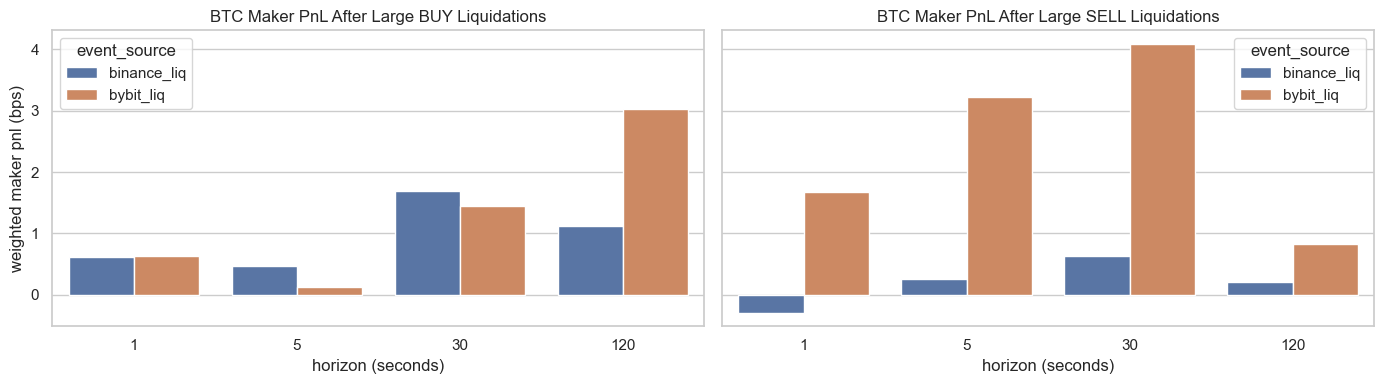

In [36]:
maker_toxicity_plot_df = pd.DataFrame([
    {'event_source': event_source, 'event_side': event_side, 'horizon_s': tau, 'weighted_maker_pnl_bps': weighted_mean(sub[f'maker_pnl_bps_{tau}s'], sub['weight'])}
    for event_source in ['binance_liq', 'bybit_liq']
    for event_side in ['buy', 'sell']
    for sub in [pnl_after_all[(pnl_after_all['event_source'] == event_source) & (pnl_after_all['event_side'] == event_side)]]
    for tau in PNL_HORIZONS_S
])

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, side in zip(axes, ['buy', 'sell']):
    sns.barplot(data=maker_toxicity_plot_df[maker_toxicity_plot_df['event_side'] == side], x='horizon_s', y='weighted_maker_pnl_bps', hue='event_source', ax=ax)
    ax.set_title(f'BTC Maker PnL After Large {side.upper()} Liquidations')
    ax.set_ylabel('weighted maker pnl (bps)')
    ax.set_xlabel('horizon (seconds)')
plt.tight_layout()
plt.show()

Trades that happen after large liquidations are not obviously toxic on average in this sample. Most of the weighted maker PnL numbers are actually positive, especially on the 30s horizon, so large liquidation events do not automatically mean that the next trades are bad for the maker

The strongest effect appears after large Bybit sell liquidations. Those are followed by the best maker PnL out of all four groups, which lines up with the earlier rebound pattern in mid-price and suggests these events may be closer to exhaustion than continuation

Binance liquidations look weaker as a predictor here. Their post-event maker PnL is positive too, but the effect is smaller and less distinct, especially on the sell side

## Nonlinearity Checks: Feature Buckets vs Future Maker PnL

This section keeps only the most useful nonlinear checks.

Goal:
- split a feature into quantile buckets
- compute mean future maker PnL inside each bucket
- check whether the shape is flat, gradual, or strongly nonlinear

We focus on three features:
- Binance liquidation notional in the last 1 second
- Bybit liquidation notional in the last 1 second
- current Binance spread in bps


In [37]:
NONLINEARITY_SYMBOL = 'btcusdt'
NONLINEARITY_TRADE_LIMIT = 1000000000

nonlin_trades = (
    with_trade_fields(scan_train('trades', NONLINEARITY_SYMBOL))
    .select(['timestamp', 'side', 'price', 'amount', 'notional'])
    .limit(NONLINEARITY_TRADE_LIMIT)
    .collect()
    .to_pandas()
    .sort_values('timestamp')
    .reset_index(drop=True)
)
nonlin_trades['maker_sign'] = nonlin_trades['side'].map({'buy': 1.0, 'sell': -1.0})

nonlin_bbo = (
    with_bbo_fields(scan_train('bbo', NONLINEARITY_SYMBOL))
    .select(['timestamp', 'bid_amount', 'ask_amount', 'spread_bps', 'mid'])
    .collect()
    .to_pandas()
    .sort_values('timestamp')
    .reset_index(drop=True)
)

nonlin_liq_binance = (
    with_liq_fields(scan_train('liq_binance', NONLINEARITY_SYMBOL))
    .select(['timestamp', 'notional'])
    .collect()
    .to_pandas()
    .sort_values('timestamp')
    .reset_index(drop=True)
)

nonlin_liq_bybit = (
    with_liq_fields(scan_train('liq_bybit', NONLINEARITY_SYMBOL))
    .select(['timestamp', 'notional'])
    .collect()
    .to_pandas()
    .sort_values('timestamp')
    .reset_index(drop=True)
)


In [38]:
def attach_future_mid_targets(trades_df: pd.DataFrame, bbo_df: pd.DataFrame, horizons_s: list[int]) -> pd.DataFrame:
    out = trades_df.copy().sort_values('timestamp').reset_index(drop=True)
    base = pd.merge_asof(
        out[['timestamp']].sort_values('timestamp'),
        bbo_df[['timestamp', 'mid']].sort_values('timestamp'),
        on='timestamp',
        direction='backward',
        allow_exact_matches=True,
    )
    out['mid_t'] = base['mid'].to_numpy()
    for tau in horizons_s:
        target = out[['timestamp']].copy()
        target['target_ts'] = target['timestamp'] + tau * 1_000_000
        future = pd.merge_asof(
            target.sort_values('target_ts'),
            bbo_df[['timestamp', 'mid']].sort_values('timestamp'),
            left_on='target_ts',
            right_on='timestamp',
            direction='backward',
            allow_exact_matches=True,
        )
        out[f'mid_future_{tau}s'] = future['mid'].to_numpy()
        out[f'maker_pnl_bps_{tau}s'] = -out['maker_sign'] * (out[f'mid_future_{tau}s'] - out['price']) / out['price'] * 10000.0 + 0.5
    return out

def rolling_feature_from_events(trades_df: pd.DataFrame, events_df: pd.DataFrame, window_s: int, feature_name: str) -> pd.Series:
    out = []
    window_us = window_s * 1_000_000
    event_ts = events_df['timestamp'].to_numpy()
    event_notional = events_df['notional'].to_numpy()
    left = 0
    right = 0
    current_sum = 0.0
    for ts in trades_df['timestamp'].to_numpy():
        while right < len(event_ts) and event_ts[right] <= ts:
            current_sum += event_notional[right]
            right += 1
        while left < right and event_ts[left] < ts - window_us:
            current_sum -= event_notional[left]
            left += 1
        out.append(current_sum)
    return pd.Series(out, name=feature_name)

def attach_bbo_context(trades_df: pd.DataFrame, bbo_df: pd.DataFrame) -> pd.DataFrame:
    merged = pd.merge_asof(
        trades_df[['timestamp']].sort_values('timestamp'),
        bbo_df[['timestamp', 'spread_bps']].sort_values('timestamp'),
        on='timestamp',
        direction='backward',
        allow_exact_matches=True,
    )
    return merged[['spread_bps']]

nonlin_features = attach_future_mid_targets(nonlin_trades, nonlin_bbo, [30])
nonlin_features['liq_notional_1s_binance'] = rolling_feature_from_events(nonlin_features, nonlin_liq_binance, 1, 'liq_notional_1s_binance')
nonlin_features['liq_notional_1s_bybit'] = rolling_feature_from_events(nonlin_features, nonlin_liq_bybit, 1, 'liq_notional_1s_bybit')
nonlin_features['spread_bps_now'] = attach_bbo_context(nonlin_features, nonlin_bbo)['spread_bps'].to_numpy()

nonlin_features = nonlin_features.dropna(subset=['mid_t', 'mid_future_30s', 'maker_pnl_bps_30s', 'spread_bps_now']).reset_index(drop=True)
print('rows used:', len(nonlin_features))

rows used: 31132597


In [39]:
def bucket_feature_vs_target(df: pd.DataFrame, feature_col: str, target_col: str, q: int = 10) -> pd.DataFrame:
    tmp = df[[feature_col, target_col]].dropna().copy()
    tmp = tmp[np.isfinite(tmp[feature_col]) & np.isfinite(tmp[target_col])].copy()

    zero_mask = tmp[feature_col] <= 0
    pos = tmp.loc[~zero_mask, feature_col]

    if pos.empty:
        tmp['bucket'] = 'zero_or_non_positive'
    else:
        n_pos_buckets = min(q, pos.nunique())
        tmp.loc[zero_mask, 'bucket'] = 'zero_or_non_positive'
        if n_pos_buckets <= 1:
            tmp.loc[~zero_mask, 'bucket'] = 'positive'
        else:
            labels = [f'positive_q{i}' for i in range(1, n_pos_buckets + 1)]
            tmp.loc[~zero_mask, 'bucket'] = pd.qcut(
                pos,
                q=n_pos_buckets,
                labels=labels,
                duplicates='drop',
            ).astype(str)

    bucket_df = (
        tmp.groupby('bucket', observed=False)
        .agg(
            count=(feature_col, 'size'),
            feature_mean=(feature_col, 'mean'),
            mean_target=(target_col, 'mean'),
        )
        .reset_index()
    )

    positive_buckets = sorted(
        [b for b in bucket_df['bucket'].astype(str) if b != 'zero_or_non_positive'],
        key=lambda x: int(x.split('q')[-1]) if 'q' in x else 0,
    )
    bucket_order = ['zero_or_non_positive'] + positive_buckets
    order_map = {bucket: idx for idx, bucket in enumerate(bucket_order)}

    bucket_df['bucket'] = bucket_df['bucket'].astype(str)
    bucket_df['bucket_index'] = bucket_df['bucket'].map(order_map)
    bucket_df = bucket_df.sort_values('bucket_index').reset_index(drop=True)
    bucket_df['share'] = bucket_df['count'] / bucket_df['count'].sum()
    return bucket_df


def plot_bucket_vs_target(df: pd.DataFrame, feature_col: str, target_col: str, title: str, q: int = 10):
    bucket_df = bucket_feature_vs_target(df, feature_col, target_col, q=q)
    display(bucket_df)
    plt.figure(figsize=(10, 4))
    plt.plot(bucket_df['bucket_index'], bucket_df['mean_target'], marker='o')
    plt.title(title)
    plt.xlabel('bucket index (zero bucket first, then positive quantiles)')
    plt.ylabel('mean maker pnl (bps)')
    plt.xticks(bucket_df['bucket_index'])
    plt.show()


,bucket,count,feature_mean,mean_target,bucket_index,share
0,zero_or_non_positive,26895140,-0.00000,-0.28371,0,0.86389
1,positive_q1,425370,0.00000,-0.46154,1,0.01366
2,positive_q2,430632,0.00000,-0.32464,2,0.01383
3,positive_q3,740400,0.00000,0.12649,3,0.02378
4,positive_q4,98591,157.86967,0.89262,4,0.00317
5,positive_q5,427149,222.87991,1.01657,5,0.01372
6,positive_q6,420441,493.21070,0.18588,6,0.01350
7,positive_q7,424237,1028.79886,1.13035,7,0.01363
8,positive_q8,423855,2248.67172,0.57692,8,0.01361
9,positive_q9,423119,6187.40101,0.30680,9,0.01359


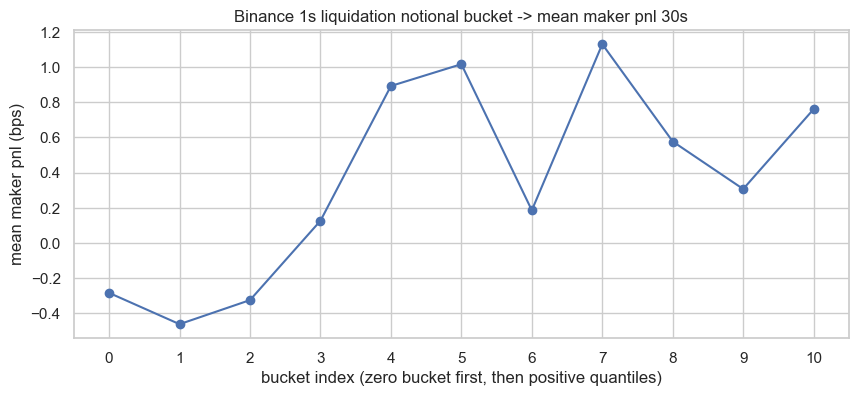

,bucket,count,feature_mean,mean_target,bucket_index,share
0,zero_or_non_positive,21702,-0.00000,-5.22637,0,0.00070
1,positive_q1,3124448,0.00000,-0.14093,1,0.10036
2,positive_q2,3125946,0.00000,-0.28964,2,0.10041
3,positive_q3,3088498,0.00000,-0.33342,3,0.09920
4,positive_q4,3260455,0.00000,-0.23081,4,0.10473
5,positive_q5,2959474,0.00000,-0.25432,5,0.09506
6,positive_q6,3142547,0.00000,-0.31447,6,0.10094
7,positive_q7,3077879,0.00000,-0.44824,7,0.09886
8,positive_q8,3131915,0.00000,-0.24796,8,0.10060
9,positive_q9,3095576,0.00000,-0.17712,9,0.09943


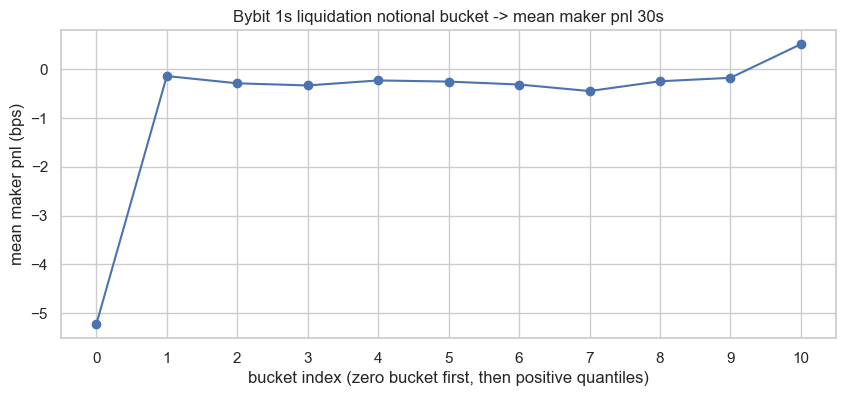

,bucket,count,feature_mean,mean_target,bucket_index,share
0,positive_q1,3113663,0.01072,-0.14920,1,0.10001
1,positive_q2,3113682,0.01078,-0.30143,2,0.10001
2,positive_q3,3112612,0.01085,-0.25169,3,0.09998
3,positive_q4,3113084,0.01094,-0.14115,4,0.09999
4,positive_q5,3113537,0.01107,-0.25464,5,0.10001
5,positive_q6,3113427,0.01119,-0.21115,6,0.10001
6,positive_q7,3112961,0.01130,-0.01722,7,0.09999
7,positive_q8,3113189,0.01152,-0.38077,8,0.10000
8,positive_q9,3113425,0.01167,-0.30026,9,0.10001
9,positive_q10,3113017,0.22298,0.04946,10,0.09999


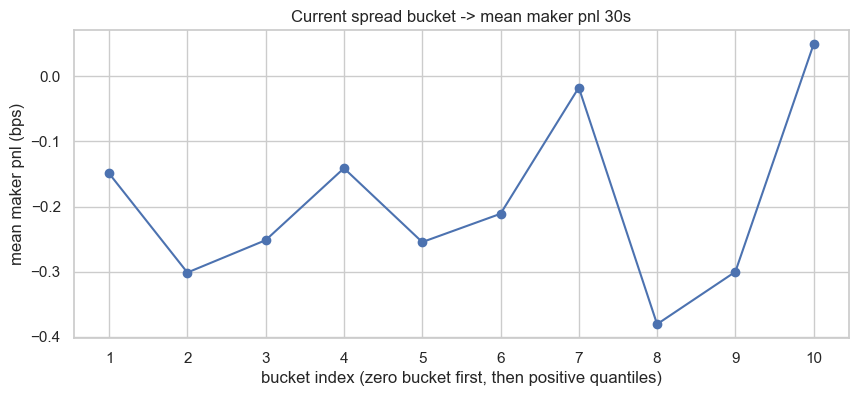

In [40]:
plot_bucket_vs_target(
    nonlin_features,
    'liq_notional_1s_binance',
    'maker_pnl_bps_30s',
    'Binance 1s liquidation notional bucket -> mean maker pnl 30s',
    q=10,
)

plot_bucket_vs_target(
    nonlin_features,
    'liq_notional_1s_bybit',
    'maker_pnl_bps_30s',
    'Bybit 1s liquidation notional bucket -> mean maker pnl 30s',
    q=10,
)

plot_bucket_vs_target(
    nonlin_features,
    'spread_bps_now',
    'maker_pnl_bps_30s',
    'Current spread bucket -> mean maker pnl 30s',
    q=10,
)

These three features do not behave in the same way. Binance 1s liquidation notional looks the most interesting here: when recent Binance liquidation flow is truly large, the average 30s maker PnL becomes positive, while the zero bucket and the smallest positive buckets are clearly worse. So the relationship is not linear, but there does seem to be a real regime shift once liquidation activity becomes large enough

Bybit 1s liquidation notional is weaker in this view. Most buckets stay slightly negative, and only the very top bucket turns clearly positive. That suggests small and medium Bybit liquidation flow is not very informative on its own, while only the most extreme events may carry useful signal

Current spread also does not show a clean monotonic pattern. Most of the distribution sits in a narrow range, and the differences across spread buckets are fairly small, so spread by itself looks more like a context feature than a standalone predictor

## Predictive Signal Search

This final section focuses on a practical question:
which features are most useful for filtering toxic maker trades?

We keep the analysis simple and directly connected to the task:
- build a compact trade-level feature table
- rank candidate features by how strongly they separate future maker PnL
- visualize the strongest candidates
- test simple threshold rules and measure whether they improve weighted maker PnL

Target used in this section:
- `maker_pnl_bps_30s`

Rule quality is measured by:
- weighted maker PnL on all trades
- weighted maker PnL on kept trades
- uplift = `PnL_kept - PnL_all`
- kept turnover share
- kept turnover USD/day



In [41]:
PRED_SYMBOL = NONLINEARITY_SYMBOL
PRED_HORIZON = 'maker_pnl_bps_30s'
PRED_DAYS = 7

pred_liq_binance = (
    with_liq_fields(scan_train('liq_binance', PRED_SYMBOL))
    .select(['timestamp', 'side', 'notional'])
    .collect()
    .to_pandas()
    .sort_values('timestamp')
    .reset_index(drop=True)
)

pred_liq_bybit = (
    with_liq_fields(scan_train('liq_bybit', PRED_SYMBOL))
    .select(['timestamp', 'side', 'notional'])
    .collect()
    .to_pandas()
    .sort_values('timestamp')
    .reset_index(drop=True)
)


def attach_bbo_feature_arrays(trade_ts: np.ndarray, bbo_df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    bbo_ts = bbo_df['timestamp'].to_numpy(dtype=np.int64)
    idx = np.searchsorted(bbo_ts, trade_ts, side='right') - 1
    valid = idx >= 0

    spread = np.full(len(trade_ts), np.nan, dtype=np.float32)
    imbalance = np.full(len(trade_ts), np.nan, dtype=np.float32)
    if valid.any():
        spread_vals = bbo_df['spread_bps'].to_numpy(dtype=np.float32)
        bid_vals = bbo_df['bid_amount'].to_numpy(dtype=np.float32)
        ask_vals = bbo_df['ask_amount'].to_numpy(dtype=np.float32)
        valid_idx = idx[valid]
        spread[valid] = spread_vals[valid_idx]
        denom = bid_vals[valid_idx] + ask_vals[valid_idx]
        imbalance[valid] = np.divide(
            bid_vals[valid_idx] - ask_vals[valid_idx],
            denom,
            out=np.zeros_like(denom, dtype=np.float32),
            where=denom != 0,
        )
    return spread, imbalance


def rolling_trade_imbalance_fast(trade_ts: np.ndarray, trade_side: np.ndarray, window_s: int) -> np.ndarray:
    side_num = np.where(trade_side == 'buy', 1.0, -1.0).astype(np.float32)
    window_us = np.int64(window_s * 1_000_000)
    left_idx = np.searchsorted(trade_ts, trade_ts - window_us, side='left')
    csum = np.concatenate(([0.0], np.cumsum(side_num, dtype=np.float64)))
    counts = np.arange(1, len(trade_ts) + 1) - left_idx
    sums = csum[1:] - csum[left_idx]
    return (sums / np.maximum(counts, 1)).astype(np.float32)


def rolling_event_sum_fast(trade_ts: np.ndarray, event_ts: np.ndarray, event_val: np.ndarray, window_s: int) -> np.ndarray:
    if len(event_ts) == 0:
        return np.zeros(len(trade_ts), dtype=np.float32)
    window_us = np.int64(window_s * 1_000_000)
    right_idx = np.searchsorted(event_ts, trade_ts, side='right')
    left_idx = np.searchsorted(event_ts, trade_ts - window_us, side='left')
    csum = np.concatenate(([0.0], np.cumsum(event_val.astype(np.float64))))
    out = csum[right_idx] - csum[left_idx]
    return out.astype(np.float32)


def rolling_side_liq_feature_fast(trade_ts: np.ndarray, trade_side: np.ndarray, events_df: pd.DataFrame, window_s: int, side_mode: str) -> np.ndarray:
    buy_events = events_df.loc[events_df['side'] == 'buy', ['timestamp', 'notional']]
    sell_events = events_df.loc[events_df['side'] == 'sell', ['timestamp', 'notional']]

    buy_roll = rolling_event_sum_fast(
        trade_ts,
        buy_events['timestamp'].to_numpy(dtype=np.int64),
        buy_events['notional'].to_numpy(dtype=np.float32),
        window_s,
    )
    sell_roll = rolling_event_sum_fast(
        trade_ts,
        sell_events['timestamp'].to_numpy(dtype=np.int64),
        sell_events['notional'].to_numpy(dtype=np.float32),
        window_s,
    )

    if side_mode == 'same':
        return np.where(trade_side == 'buy', buy_roll, sell_roll).astype(np.float32)
    if side_mode == 'opposite':
        return np.where(trade_side == 'buy', sell_roll, buy_roll).astype(np.float32)
    raise ValueError('side_mode must be same or opposite')


pred_features = nonlin_features[[
    'timestamp',
    'side',
    'notional',
    PRED_HORIZON,
    'liq_notional_1s_binance',
    'liq_notional_1s_bybit',
]].copy()

trade_ts = pred_features['timestamp'].to_numpy(dtype=np.int64)
trade_side = pred_features['side'].to_numpy()

pred_features['liq_notional_1s_total'] = (
    pred_features['liq_notional_1s_binance'].to_numpy(dtype=np.float32)
    + pred_features['liq_notional_1s_bybit'].to_numpy(dtype=np.float32)
).astype(np.float32)

spread_bps_now, bbo_imbalance_now = attach_bbo_feature_arrays(trade_ts, nonlin_bbo)
pred_features['spread_bps_now'] = spread_bps_now
pred_features['bbo_imbalance_now'] = bbo_imbalance_now
pred_features['trade_imbalance_10s'] = rolling_trade_imbalance_fast(trade_ts, trade_side, 10)

pred_features['same_side_liq_1s_binance'] = rolling_side_liq_feature_fast(trade_ts, trade_side, pred_liq_binance, 1, 'same')
pred_features['opposite_side_liq_1s_binance'] = rolling_side_liq_feature_fast(trade_ts, trade_side, pred_liq_binance, 1, 'opposite')
pred_features['same_side_liq_1s_bybit'] = rolling_side_liq_feature_fast(trade_ts, trade_side, pred_liq_bybit, 1, 'same')
pred_features['opposite_side_liq_1s_bybit'] = rolling_side_liq_feature_fast(trade_ts, trade_side, pred_liq_bybit, 1, 'opposite')

pred_features['weight'] = pred_features['notional'].clip(upper=100_000).astype(np.float32)

float32_cols = [
    PRED_HORIZON,
    'liq_notional_1s_binance',
    'liq_notional_1s_bybit',
    'liq_notional_1s_total',
    'spread_bps_now',
    'bbo_imbalance_now',
    'trade_imbalance_10s',
    'same_side_liq_1s_binance',
    'opposite_side_liq_1s_binance',
    'same_side_liq_1s_bybit',
    'opposite_side_liq_1s_bybit',
    'weight',
]
pred_features[float32_cols] = pred_features[float32_cols].astype(np.float32)

pred_features = pred_features.dropna(subset=[PRED_HORIZON, 'spread_bps_now', 'bbo_imbalance_now']).reset_index(drop=True)
print('rows used for predictive search:', len(pred_features))


rows used for predictive search: 31132597


In [42]:
candidate_features = [
    'liq_notional_1s_binance',
    'liq_notional_1s_bybit',
    'liq_notional_1s_total',
    'same_side_liq_1s_binance',
    'opposite_side_liq_1s_binance',
    'same_side_liq_1s_bybit',
    'opposite_side_liq_1s_bybit',
    'spread_bps_now',
    'bbo_imbalance_now',
    'trade_imbalance_10s',
]


def weighted_mean_safe(values: pd.Series, weights: pd.Series) -> float:
    mask = np.isfinite(values) & np.isfinite(weights)
    if mask.sum() == 0 or weights[mask].sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])


def feature_signal_summary(df: pd.DataFrame, feature_col: str, target_col: str) -> dict:
    tmp = df[[feature_col, target_col, 'weight', 'notional']].dropna().copy()
    if len(tmp) < 100:
        return None
    low_q = tmp[feature_col].quantile(0.10)
    high_q = tmp[feature_col].quantile(0.90)
    low = tmp[tmp[feature_col] <= low_q]
    high = tmp[tmp[feature_col] >= high_q]
    bad = tmp[target_col] < 0
    return {
        'feature': feature_col,
        'nonzero_share': float((tmp[feature_col] > 0).mean()),
        'spearman': float(tmp[[feature_col, target_col]].corr(method='spearman').iloc[0, 1]),
        'mean_target_low_decile': float(low[target_col].mean()),
        'mean_target_high_decile': float(high[target_col].mean()),
        'weighted_target_low_decile': float(weighted_mean_safe(low[target_col], low['weight'])),
        'weighted_target_high_decile': float(weighted_mean_safe(high[target_col], high['weight'])),
        'mean_gap_high_minus_low': float(high[target_col].mean() - low[target_col].mean()),
        'bad_rate_low_decile': float((low[target_col] < 0).mean()),
        'bad_rate_high_decile': float((high[target_col] < 0).mean()),
    }

signal_rows = []
for feature in candidate_features:
    row = feature_signal_summary(pred_features, feature, PRED_HORIZON)
    if row is not None:
        signal_rows.append(row)

signal_summary = pd.DataFrame(signal_rows)
signal_summary['abs_mean_gap'] = signal_summary['mean_gap_high_minus_low'].abs()
signal_summary = signal_summary.sort_values(['abs_mean_gap', 'bad_rate_high_decile'], ascending=[False, False]).reset_index(drop=True)
display(signal_summary)

,feature,nonzero_share,spearman,mean_target_low_decile,mean_target_high_decile,weighted_target_low_decile,weighted_target_high_decile,mean_gap_high_minus_low,bad_rate_low_decile,bad_rate_high_decile,abs_mean_gap
0,liq_notional_1s_binance,0.13611,0.01843,-0.28012,0.59123,-0.16654,1.09182,0.87135,0.51702,0.48051,0.87135
1,liq_notional_1s_total,0.99943,0.01723,-0.18668,0.62180,-0.03255,1.10091,0.80848,0.51128,0.47821,0.80848
2,liq_notional_1s_bybit,0.99930,0.01450,-0.17601,0.50722,0.02473,0.96605,0.68323,0.50968,0.48006,0.68323
3,spread_bps_now,1.00000,-0.00098,-0.14920,0.04952,-0.00199,0.69047,0.19872,0.51152,0.50667,0.19872
4,same_side_liq_1s_binance,0.05128,0.04991,-0.30219,-0.19581,-0.24708,-0.03357,0.10638,0.51579,0.51166,0.10638
5,same_side_liq_1s_bybit,0.03934,0.05369,-0.29812,-0.19581,-0.23277,-0.03357,0.10231,0.51551,0.51166,0.10231
6,bbo_imbalance_now,0.50201,0.00621,-0.33196,-0.28968,0.00464,0.26689,0.04228,0.52467,0.51833,0.04228
7,opposite_side_liq_1s_binance,0.03353,-0.01915,-0.16757,-0.19581,0.01797,-0.03357,-0.02824,0.51053,0.51166,0.02824
8,opposite_side_liq_1s_bybit,0.02444,-0.01946,-0.17184,-0.19581,0.00263,-0.03357,-0.02397,0.51069,0.51166,0.02397
9,trade_imbalance_10s,0.50259,0.00090,-0.26863,-0.26558,-0.28139,-0.03272,0.00305,0.51304,0.50652,0.00305


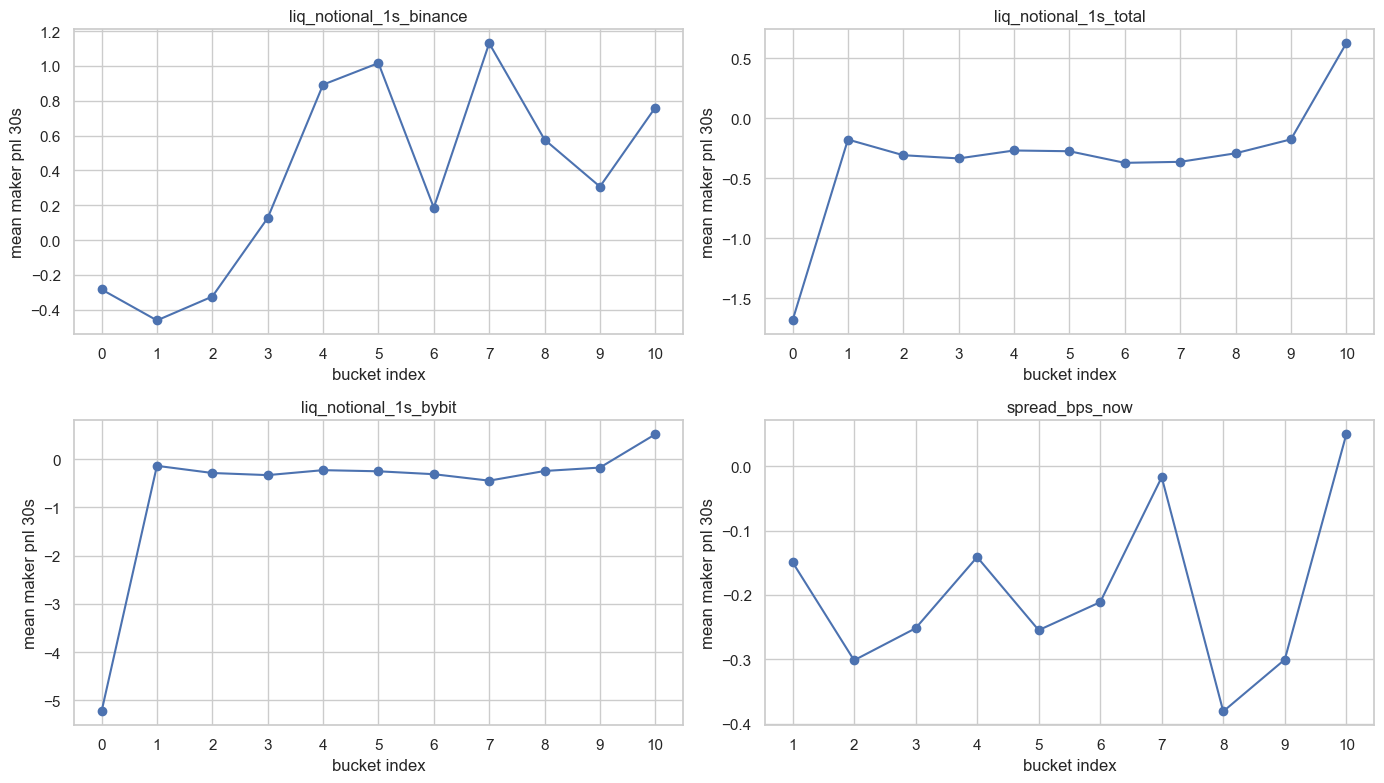

In [43]:
top_features = signal_summary.head(4)['feature'].tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for ax, feature in zip(axes, top_features):
    bucket_df = bucket_feature_vs_target(pred_features, feature, PRED_HORIZON, q=10)
    ax.plot(bucket_df['bucket_index'], bucket_df['mean_target'], marker='o')
    ax.set_title(feature)
    ax.set_xlabel('bucket index')
    ax.set_ylabel('mean maker pnl 30s')
    ax.set_xticks(bucket_df['bucket_index'])
for ax in axes[len(top_features):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [44]:
rule_features = signal_summary.head(6)['feature'].tolist()
rule_quantiles = [0.80, 0.90, 0.95, 0.99]

base_target = pred_features[PRED_HORIZON].to_numpy(dtype=float)
base_weight = pred_features['weight'].to_numpy(dtype=float)
base_notional = pred_features['notional'].to_numpy(dtype=float)
base_valid = np.isfinite(base_target) & np.isfinite(base_weight) & np.isfinite(base_notional)

base_target_valid = base_target[base_valid]
base_weight_valid = base_weight[base_valid]
base_notional_valid = base_notional[base_valid]

pnl_all = float(np.average(base_target_valid, weights=base_weight_valid))
total_notional = float(base_notional_valid.sum())
row_count = len(pred_features)


def evaluate_filter_rule_fast(feature_values: np.ndarray, threshold: float, direction: str = 'high') -> dict | None:
    valid = base_valid & np.isfinite(feature_values)
    if valid.sum() == 0:
        return None

    x = feature_values[valid]
    y = base_target[valid]
    w = base_weight[valid]
    n = base_notional[valid]

    if direction == 'high':
        filtered = x >= threshold
    elif direction == 'low':
        filtered = x <= threshold
    else:
        raise ValueError('direction must be high or low')

    kept_mask = ~filtered
    if kept_mask.sum() == 0:
        return None

    kept_weight = w[kept_mask]
    if kept_weight.sum() == 0:
        return None

    kept_target = y[kept_mask]
    kept_notional = n[kept_mask]
    pnl_kept = float(np.average(kept_target, weights=kept_weight))
    kept_notional_sum = float(kept_notional.sum())

    return {
        'direction': direction,
        'threshold': float(threshold),
        'filtered_share': float(filtered.mean()),
        'kept_share': float(kept_mask.mean()),
        'kept_turnover_share': float(kept_notional_sum / total_notional),
        'kept_turnover_usd_per_day': float(kept_notional_sum / PRED_DAYS),
        'pnl_all_bps': pnl_all,
        'pnl_kept_bps': pnl_kept,
        'uplift_bps': float(pnl_kept - pnl_all),
    }


rule_rows = []
for feature in tqdm(rule_features, desc='Features'):
    feature_values = pred_features[feature].to_numpy(dtype=float)
    finite_feature = feature_values[np.isfinite(feature_values)]
    if len(finite_feature) == 0:
        continue
    for q in tqdm(rule_quantiles, desc=f'Thresholds for {feature}', leave=False):
        high_threshold = float(np.nanquantile(finite_feature, q))
        low_threshold = float(np.nanquantile(finite_feature, 1 - q))

        row_high = evaluate_filter_rule_fast(feature_values, high_threshold, 'high')
        row_low = evaluate_filter_rule_fast(feature_values, low_threshold, 'low')

        if row_high is not None:
            row_high['feature'] = feature
            row_high['quantile'] = q
            rule_rows.append(row_high)
        if row_low is not None:
            row_low['feature'] = feature
            row_low['quantile'] = 1 - q
            rule_rows.append(row_low)

rule_search = pd.DataFrame(rule_rows)
rule_search = rule_search.sort_values(['uplift_bps', 'kept_turnover_usd_per_day'], ascending=[False, False]).reset_index(drop=True)
display(rule_search.head(20))


Features:   0%|          | 0/6 [00:00<?, ?it/s]

Thresholds for liq_notional_1s_binance:   0%|          | 0/4 [00:00<?, ?it/s]

Thresholds for liq_notional_1s_total:   0%|          | 0/4 [00:00<?, ?it/s]

Thresholds for liq_notional_1s_bybit:   0%|          | 0/4 [00:00<?, ?it/s]

Thresholds for spread_bps_now:   0%|          | 0/4 [00:00<?, ?it/s]

Thresholds for same_side_liq_1s_binance:   0%|          | 0/4 [00:00<?, ?it/s]

Thresholds for same_side_liq_1s_bybit:   0%|          | 0/4 [00:00<?, ?it/s]

,direction,threshold,filtered_share,kept_share,kept_turnover_share,kept_turnover_usd_per_day,pnl_all_bps,pnl_kept_bps,uplift_bps,feature,quantile
0,low,0.00000,0.96066,0.03934,0.06773,1075119972.65426,-0.03357,2.85820,2.89177,same_side_liq_1s_bybit,0.20000
1,low,0.00000,0.96066,0.03934,0.06773,1075119972.65426,-0.03357,2.85820,2.89177,same_side_liq_1s_bybit,0.10000
2,low,0.00000,0.96066,0.03934,0.06773,1075119972.65426,-0.03357,2.85820,2.89177,same_side_liq_1s_bybit,0.05000
3,low,0.00000,0.96066,0.03934,0.06773,1075119972.65426,-0.03357,2.85820,2.89177,same_side_liq_1s_bybit,0.01000
4,low,0.00000,0.94872,0.05128,0.08605,1365929672.71537,-0.03357,2.36255,2.39612,same_side_liq_1s_binance,0.20000
5,low,0.00000,0.94872,0.05128,0.08605,1365929672.71537,-0.03357,2.36255,2.39612,same_side_liq_1s_binance,0.10000
6,low,0.00000,0.94872,0.05128,0.08605,1365929672.71537,-0.03357,2.36255,2.39612,same_side_liq_1s_binance,0.05000
7,low,0.00000,0.94872,0.05128,0.08605,1365929672.71537,-0.03357,2.36255,2.39612,same_side_liq_1s_binance,0.01000
8,low,0.00000,0.86389,0.13611,0.18415,2923194718.32036,-0.03357,0.85841,0.89198,liq_notional_1s_binance,0.20000
9,low,0.01081,0.20003,0.79997,0.81040,12864139068.64739,-0.03357,-0.00245,0.03112,spread_bps_now,0.20000


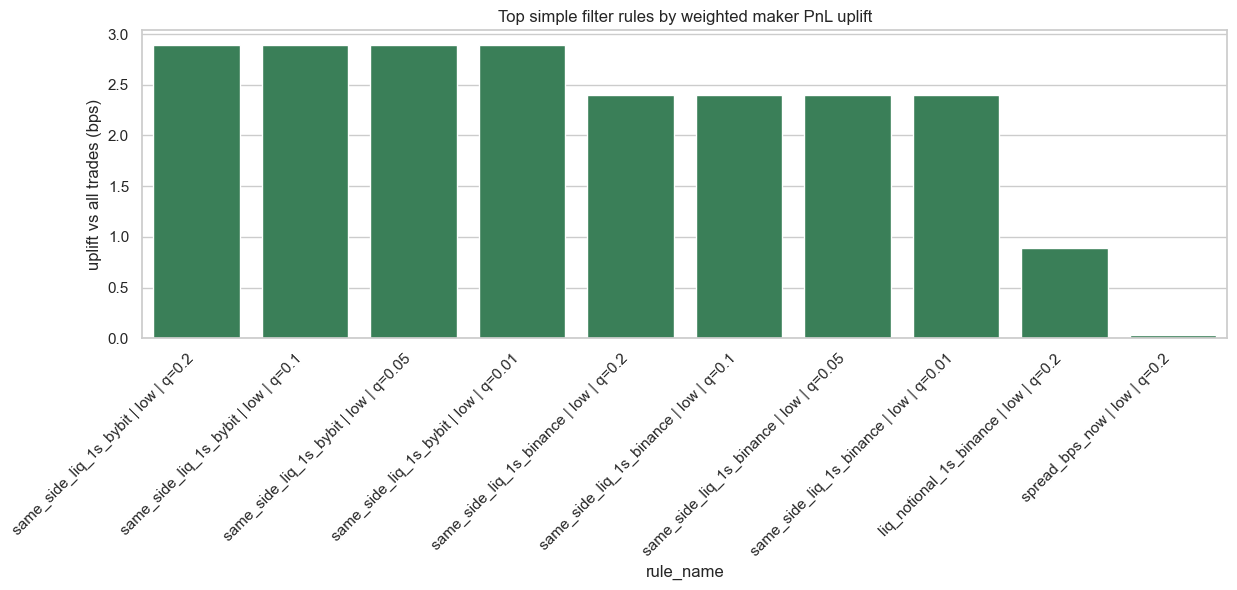

In [45]:
best_rules_plot = rule_search.head(10).copy()
best_rules_plot['rule_name'] = best_rules_plot['feature'] + ' | ' + best_rules_plot['direction'] + ' | q=' + best_rules_plot['quantile'].round(2).astype(str)

plt.figure(figsize=(14, 4))
sns.barplot(data=best_rules_plot, x='rule_name', y='uplift_bps', color='seagreen')
plt.title('Top simple filter rules by weighted maker PnL uplift')
plt.ylabel('uplift vs all trades (bps)')
plt.xticks(rotation=45, ha='right')
plt.show()

The strongest rules in the updated search all come from the same idea: keep trades only when there was some nonzero same-side liquidation flow in the last second. The best version uses same_side_liq_1s_bybit, and it gives a very large uplift in weighted maker PnL, but it does so by keeping only about 4% of trades and around 7% of turnover

The next-best rules show the same pattern for same_side_liq_1s_binance. They are slightly weaker than the Bybit version, but still much stronger than broad liquidation totals or spread alone, which suggests that side-aware liquidation context matters more than just raw event intensity

## Executive Summary

### Practical takeaways

- `Trades` are still the main computational bottleneck, while liquidation files are relatively small and easy to work with
- `BBO` is fairly stable, but `trades` and especially `liquidations` are bursty and clearly regime-dependent
- Bybit has more BTC liquidation activity than Binance, both in event count and in total notional
- Binance and Bybit liquidation streams are highly synchronized, so they should be treated as overlapping stress signals rather than fully independent sources
- Large liquidation events do not automatically make the next trades toxic for the maker; in several cases the post-event behavior looks closer to rebound or exhaustion than to pure continuation
- The most useful signal in this notebook is not raw liquidation intensity by itself, but very recent `same-side` liquidation pressure
- The best simple rules improve maker PnL a lot, but they do it by keeping only a very small share of trades and turnover

### What looks most promising for a predictive signal

| Candidate | Why it matters | Current verdict |
|---|---|---|
| `same_side_liq_1s_bybit` | This was the strongest feature in the simple rule search and gave the largest uplift | Most promising single feature, but far too aggressive alone |
| `same_side_liq_1s_binance` | Also produced a strong uplift and was slightly weaker than the Bybit version | Strong candidate, likely useful together with other filters |
| Raw liquidation totals | Some uplift is still there, but much weaker than in side-aware versions | Less useful than same-side liquidation context |
| `spread_bps_now` | Captures stress conditions, but adds only a small standalone improvement | Better as a context feature than as a primary signal |
| Trade imbalance / regime features | Can help separate calm, active, and stressed market states | Good candidate for interaction features in the next iteration |